## **Agent Tool Selection Strategies**
#### **Understanding Exploration vs. Exploitation in Production AI Systems**

> **Author:** Isaac Cobena Appiah</br> 
> **Date:** January, 2026</br> 
> **Type:** Medium/Substack/Website (talkcodetome.com) Tutorial
> 
*Why tool selection is the hardest decision an agent makes — set up as a multi-armed bandit, with a synthetic environment and a hard look at signal vs. noise.*

> **Series:** Part 1 · Part 2 · Part 3 · Part 4 · Part 5  —  *you are reading Part 1.*
### **An Introduction to How AI Agents Choose Their Tools**

AI agents can now search the web, query databases, call APIs, write code, schedule meetings, and act on software on our behalf. But an agent is only as effective as the decisions it makes about **which tool to use**.

Imagine an agent with access to ten different tools: a database lookup, web search, calculator, knowledge base, order tracker, refund processor, scheduling API, analytics engine, email service, and human escalation. Every time a new request arrives, the agent faces the same question:

> **Which tool should I choose?**

At first glance, the answer seems obvious: use the tool that worked last time. Unfortunately, that is exactly how many agents get stuck.

Suppose a customer asks, *"Where is my order?"* The first time, the agent answers correctly using a web search. The next customer asks something similar, so it reaches for web search again. Then again. Eventually it routes almost every request through the same tool — even when a direct database lookup would answer in milliseconds, or the knowledge base would return a more accurate response.

The problem is not that the agent *cannot* use the other tools; it simply has no reason to believe they would perform any better.

This behaviour is known as **greedy exploitation**, and it sits at the heart of one of the most important problems in reinforcement learning and agentic AI: the **exploration–exploitation trade-off**. Should an agent keep using the tool it already trusts, or occasionally try another that might perform even better?

Every autonomous system faces this dilemma.

- **Customer support agent** : Use the familiar FAQ search or try the database?
- **Coding assistant**       : Search previous code or explore the documentation?                  
- **Research agent**         : Query trusted sources or investigate new ones?                      
- **Browser agent**          : Follow the known navigation path or test another route?             
- **Medical assistant**      : Use the standard diagnostic workflow or consult a specialist model? 
- **Trading system**         : Execute a proven strategy or evaluate a new one?                    

Choose too little exploration, and the agent may never discover better tools. Explore too aggressively, and it wastes time, money, and user trust. Designing an agent that balances these competing goals is one of the central challenges in modern AI systems.

In this tutorial, we'll build that intuition from first principles. Rather than treating the exploration–exploitation trade-off as abstract theory, we'll create a small simulation environment in Python where several tools compete over thousands of interactions. We'll implement increasingly sophisticated decision strategies, visualise how they learn, and see why some approaches consistently outperform others.

If you're comfortable with basic Python, NumPy, and a little object-oriented programming, you have everything you need. We'll develop the underlying mathematics, algorithms, and visualizations step by step from the ground up, and by the end you'll understand not only **how AI agents choose their tools**, but **why those decisions determine whether an agent succeeds or fails in production**.

#### **Why build a simulation at all?**

One of the most valuable habits in AI engineering is learning to build **controlled experiments**. Production agents operate in environments that are noisy, expensive to evaluate, difficult to reproduce, and often constrained by privacy or safety requirements. Before deploying a new decision strategy, we should be able to simulate it, observe how it behaves under different conditions, and identify where it is likely to fail.

That is exactly what we'll do here. Instead of experimenting on a live customer-support agent, we'll build a synthetic environment where the available tools and their success rates are entirely under our control. Unlike production systems — where the optimal action is unknown — we know the underlying **ground truth** inside our simulation. This lets us measure precisely how quickly each strategy discovers the best tool, and how much reward it sacrifices while learning.

The distinction we'll return to throughout is fundamental:

* **A guessing agent** selects tools using fixed rules, intuition, or simple heuristics.
* **A learning agent** continually updates its beliefs from experience, improving its decisions over time.

We'll implement both approaches from scratch, compare their behavior under identical conditions, and build an intuition for why successful AI agents must balance **exploration** with **exploitation**.

#### **What We Will Build (Full Outline)**

1. [Environment Setup](#setup)
2. [The Multi-Armed Bandit — The Foundation](#bandit)
3. [Build the Synthetic Agent Environment](#environment)
4. [Signal vs. Noise in Tool Environments](#signal-noise)
5. [Greedy Agent — High Bias, Low Variance](#greedy)
6. [Random Agent — Low Bias, High Variance](#random)
7. [Epsilon-Greedy — Finding the Sweet Spot](#epsilon)
8. [Upper Confidence Bound (UCB) Agent](#ucb)
9. [The 9-Trial Comparison Grid](#nine-trial)
10. [Learning Curves — Visual Trade-off Analysis](#learning)
11. [The Exploration-Exploitation Decomposition](#decomposition)
12. [Epsilon Sensitivity Analysis](#epsilon-analysis)
13. [Advanced Environments — Cost, Drift, Positional Bias](#advanced-env)
14. [Production AI Engineering Perspective](#production)
15. [Advanced Architectures](#advanced-arch)
16. [Engineering Best Practices](#checklist)
17. [Putting It All Together](#summary)

With that foundation in place, we can set up the simulation environment and define the parameters every experiment will share.
### **1. Environment Setup**

Before building any agents, we need a reproducible simulation environment. Unlike production systems — where every experiment may involve live users, external APIs, or shifting data — our simulation should behave identically every time it runs. This lets us compare decision strategies fairly and attribute performance differences to the algorithms themselves rather than to random chance.

To achieve this, we first import the libraries that will support the whole project, establish a few global configuration variables, and fix a random seed for reproducibility. Every experiment in the tutorial uses these same settings so results stay directly comparable.

**Why this step matters**

A well-configured experimental environment provides several benefits:

* **Reproducibility** — every simulation can be recreated exactly.
* **Fair comparison** — competing strategies run under identical conditions.
* **Consistent visualisations** — every plot shares the same styling and colour conventions.
* **Maintainability** — global parameters live in one place and can be changed without touching the rest of the notebook.

Without these foundations, two agents may appear to perform differently simply because they encountered different random events rather than because one strategy is genuinely better.

### **What we'll configure**

At the beginning of the project, we'll define:

* Python library imports
* Global random seed
* Simulation parameters
* Plotting defaults
* Color palette for comparing algorithms
* and the task–tool definitions used throughout the notebook.

Keeping these settings centralized makes the project easier to understand, reproduce, and extend.

#### **Engineering Best Practices**

As simulations grow, a few habits pay off: use descriptive names, avoid hard-coded "magic numbers", isolate reusable logic into functions or classes, keep the environment definition separate from the agent implementation, and keep experiments deterministic wherever possible.

#### **Production Perspective**

Although our environment is synthetic, the workflow mirrors how reinforcement-learning systems are often developed in practice. Rather than experimenting directly in production, engineers validate new algorithms in controlled simulators where performance can be measured safely, repeatedly, and cheaply. Once a strategy performs well in simulation, it can be evaluated in progressively more realistic environments before deployment.

#### **Importing the Required Libraries**

This project relies on a small scientific Python stack:

* **NumPy**  : for numerical computation and random sampling 
* **Matplotlib** : for static visualizations (`gridspec` and `patches` handle layout and annotations)
* **Seaborn** : for plot styling and statistical aesthetics
* **collections** (`defaultdict`, `Counter`) — lightweight bookkeeping of tasks and outcomes
* **warnings** — kept quiet so the notebook output stays clean

Together these provide everything we need to build, evaluate, and visualise multi-armed bandit algorithms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
import warnings

warnings.filterwarnings("ignore")

#### **Ensuring Reproducible Experiments**

Many components of this project are intentionally stochastic.

Examples include:

* randomly generated tasks,
* stochastic tool rewards,
* exploration decisions,
* randomized agent behaviour.

Without fixing the random seed, every notebook execution would produce slightly different results, making it difficult to compare algorithms or verify conclusions.

To ensure every algorithm is evaluated under identical conditions, we define a single global seed.

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Next, we establish the global parameters that control every experiment in the tutorial.
#### **Defining the Simulation Parameters**

Rather than scattering configuration values throughout the notebook, we define them once at the beginning.

Examples include:

* number of available tools
* number of simulated tasks
* number of interaction rounds
* exploration rates
* confidence parameters
* plotting colors

In [3]:
N_TASKS        = 200     # Tasks per simulation run
N_TRIALS       = 9       # Repeated trials per strategy (for 3×3 grid)
N_AVG_TRIALS   = 50      # Trials for averaged learning curves
N_STRATEGIES   = 4       # Greedy, Random, Epsilon-Greedy, UCB

Keeping these values in one place makes the simulation easier to modify and guarantees consistency across every experiment.
#### **Defining the Agent's Available Tools**
Our agent has access to five different tools.

In [4]:
TOOLS = {
    'search_faq':       'Search FAQ database (fast, focused)',
    'query_database':   'Retrieve customer records (accurate, specific)',
    'web_search':       'Search external web (broad, noisy)',
    'calculator':       'Perform calculations (deterministic)',
    'email_api':        'Escalate to human support',
}
TOOL_NAMES = list(TOOLS.keys())
N_TOOLS    = len(TOOL_NAMES)

These tools intentionally resemble those available to real customer-support agents. Each tool performs well for certain tasks but poorly for others, forcing the agent to learn which one to select.
#### **Defining the Task Environment**

Next, we define the different requests the agent may receive.

In [5]:
TASK_TYPES = {
    'order_status':    {'optimal_tool': 'query_database', 'base_success': 0.95},
    'password_reset':  {'optimal_tool': 'search_faq',     'base_success': 0.90},
    'calculation':     {'optimal_tool': 'calculator',     'base_success': 1.00},
    'return_policy':   {'optimal_tool': 'web_search',     'base_success': 0.75},
    'complex_issue':   {'optimal_tool': 'email_api',      'base_success': 0.82},
}
TASK_NAMES = list(TASK_TYPES.keys())
N_TASKS_T  = len(TASK_NAMES)

Each task has an optimal tool and an associated probability of success. This mapping represents the hidden ground truth of our simulation.

Importantly, **the agent never sees this table**. It must discover these relationships through experience alone.
#### **Establishing Consistent Visual Design**

Since we'll compare several learning strategies throughout the tutorial, we assign each algorithm a consistent color that will be reused across every figure.

In [6]:
PALETTE = {
    'greedy':      '#e74c3c',    # Red    — greedy (high bias)
    'random':      '#9b59b6',    # Purple — random (high variance)
    'epsilon':     '#27ae60',    # Green  — epsilon-greedy (balanced)
    'ucb':         '#2980b9',    # Blue   — UCB (intelligent)
    'optimal':     '#2c3e50',    # Dark   — optimal signal line
    'noise':       '#95a5a6',    # Grey   — noise / background
    'highlight':   '#f39c12',    # Amber  — emphasis
    'background':  '#f8f9fa',    # Light  — panel backgrounds
    'reward':      '#1abc9c',    # Teal   — reward/success signal
}

STRATEGY_COLORS = {
    'Greedy':           PALETTE['greedy'],
    'Random':           PALETTE['random'],
    'Epsilon-Greedy':   PALETTE['epsilon'],
    'UCB':              PALETTE['ucb'],
}

Using the same visual language throughout the project makes the results easier to interpret as the experiments become more complex.
#### **Configuring Plot Defaults**

Finally, we configure Matplotlib once at the beginning so every visualization follows the same style.

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 110, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'font.size': 9, 'lines.linewidth': 2.2,
})

Then we verify the environment before building our first agent. It's good practice to verify that the simulation environment has been configured correctly.

In [8]:
print(f"Random state  : {RANDOM_STATE}")
print(f"Tasks / run   : {N_TASKS}")
print(f"Trials        : {N_TRIALS} per strategy (grid) | {N_AVG_TRIALS} (learning curves)")
print(f"Tools         : {N_TOOLS} — {TOOL_NAMES}")
print(f"Task types    : {N_TASKS_T} — {TASK_NAMES}")
print()
print("Ground Truth Environment (Hidden from the Agent):")
print(f"{'Task':<20} {'Optimal Tool':<20} {'Base Success'}")
print(" ")
for task, info in TASK_TYPES.items():
    print(f"{task:<20} {info['optimal_tool']:<20} {info['base_success']:.0%}")

Random state  : 42
Tasks / run   : 200
Trials        : 9 per strategy (grid) | 50 (learning curves)
Tools         : 5 — ['search_faq', 'query_database', 'web_search', 'calculator', 'email_api']
Task types    : 5 — ['order_status', 'password_reset', 'calculation', 'return_policy', 'complex_issue']

Ground Truth Environment (Hidden from the Agent):
Task                 Optimal Tool         Base Success
 
order_status         query_database       95%
password_reset       search_faq           90%
calculation          calculator           100%
return_policy        web_search           75%
complex_issue        email_api            82%


### **2. The Multi-Armed Bandit Problem**

Before we build our first agent, we need to understand the mathematical problem it is trying to solve. Although modern AI agents may call APIs, search the web, query databases, or execute code, they are all making the same fundamental decision:

> **Which action should I take next?**

This question is formalized by one of the most influential problems in machine learning and reinforcement learning: the **multi-armed bandit**.

The name comes from an old casino analogy. Imagine standing in front of several slot machines (traditionally called *one-armed bandits*). Each machine has an unknown probability of paying out, and you have a limited number of pulls. Your objective is simple: maximize the total reward you collect.

This immediately raises a fundamental question: should the agent exploit the tool it currently believes is best, or explore alternatives that could yield even greater rewards? 

This is known as the **exploration–exploitation trade-off**, and it lies at the heart of nearly every intelligent decision-making system.

For AI agents, the analogy maps almost perfectly.

| Casino                     | AI Agent                     |
| -------------------------- | ---------------------------- |
| Slot machine               | Tool                         |
| Pull                       | Tool invocation              |
| Payout                     | Reward or successful outcome |
| Unknown payout probability | Unknown tool effectiveness   |
| Player                     | Agent                        |

Every time an agent receives a task, it must decide which tool to invoke. Some tools have worked well before, while others remain uncertain. Choosing only familiar tools may prevent the agent from discovering better alternatives. Exploring too aggressively, however, wastes time, computational resources, and user trust.

Mathematically, the interaction unfolds as follows.

```
At each time step t:

1. The agent selects one of K available tools from {1, ..., K}.
2. The environment returns a reward r_t ~ P(reward | tool=a_t, task=context).
3. The agent updates its estimate of that tool's quality.
4. The process repeats.
```

The objective is to maximize the cumulative reward collected over many interactions while minimizing **regret**—the performance gap between the agent's decisions and those of an ideal strategy that always knew the best tool.

If this trade-off sounds familiar, that's because we've seen it before in supervised learning.

A very simple regression model has high bias: it makes stable predictions but consistently misses complex patterns. An overly flexible model has high variance: it can fit the training data extremely well but often fails to generalize. Effective machine learning lies between these two extremes.

Tool-selection strategies face the same challenge.

| Strategy                     | Behaviour                                                              |
| ---------------------------- | ---------------------------------------------------------------------- |
| Greedy                       | Explores too little and may become trapped in a suboptimal choice      |
| Random                       | Explores constantly but never fully exploits what it learns            |
| Epsilon-Greedy               | Mostly exploits while occasionally exploring                           |
| Upper Confidence Bound (UCB) | Explores uncertain options intelligently based on confidence estimates |

Rather than discussing these ideas only in theory, we'll build each strategy ourselves and watch them compete inside a controlled simulation. Seeing how they learn over time provides a much deeper understanding than equations alone.

With the theory in place, our next step is to visualize the bandit problem before implementing the environment and the agents themselves.
#### **2. Visualizing the Multi-Armed Bandit Problem**
The figure below illustrates the three ideas at the heart of every bandit problem:

* the **true** performance of each tool (which the agent never knows),
* the **noisy observations** the agent actually learns from,
* and the **cost of poor decisions**, measured as cumulative regret.

Understanding these three concepts makes the exploration–exploitation trade-off much more intuitive.

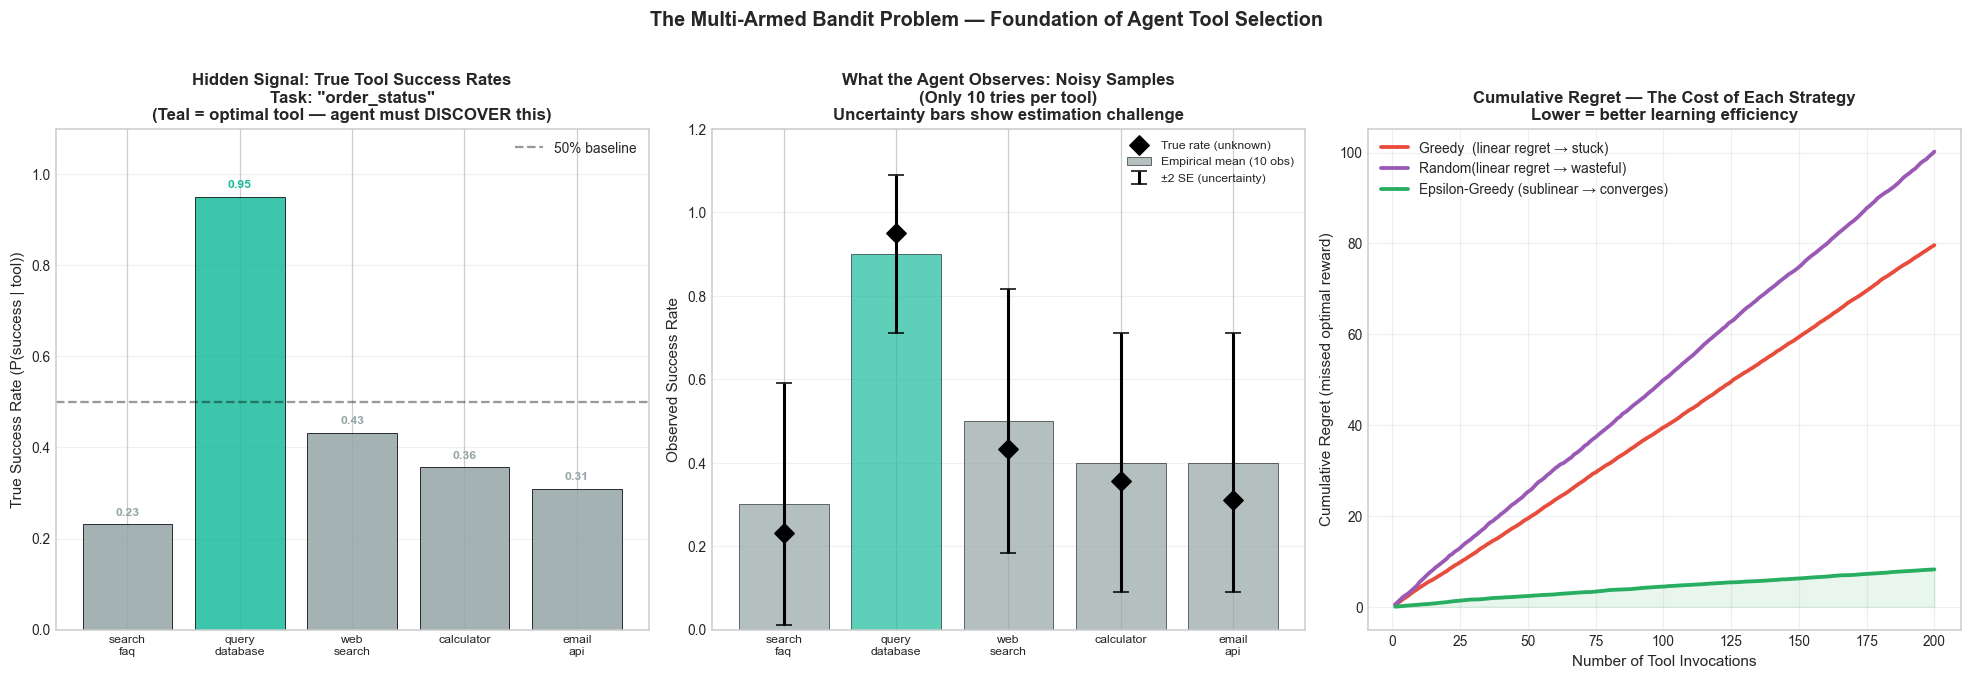

True Tool Success Rates (hidden from agent):
order_status        : optimal=query_database       P(success)=0.95
password_reset      : optimal=search_faq           P(success)=0.90
calculation         : optimal=calculator           P(success)=1.00
return_policy       : optimal=web_search           P(success)=0.75
complex_issue       : optimal=email_api            P(success)=0.82


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: True tool success rates (the hidden signal)
ax1 = axes[0]

# Example task used purely for illustration
task_shown = 'order_status'
true_rates = {}
for tool in TOOL_NAMES:
    # Optimal tool gets base_success; others get much lower rates
    if tool == TASK_TYPES[task_shown]['optimal_tool']:
        true_rates[tool] = TASK_TYPES[task_shown]['base_success']
    else:
        true_rates[tool] = np.random.uniform(0.1, 0.45)

bar_colors = [PALETTE['reward'] if t == TASK_TYPES[task_shown]['optimal_tool']
              else PALETTE['noise'] for t in TOOL_NAMES]
bars = ax1.bar(range(N_TOOLS), [true_rates[t] for t in TOOL_NAMES],
               color = bar_colors, edgecolor = 'black', lw = 0.6, alpha = 0.85)
ax1.set_xticks(range(N_TOOLS))
ax1.set_xticklabels([t.replace('_', '\n') for t in TOOL_NAMES], fontsize=8)
ax1.set_ylabel('True Success Rate (P(success | tool))')
ax1.set_title(f'Hidden Signal: True Tool Success Rates\nTask: "{task_shown}"\n'
              f'(Teal = optimal tool — agent must DISCOVER this)',
              fontweight = 'bold')
ax1.set_ylim(0, 1.1)
ax1.axhline(0.5, color = 'black', ls = '--', lw = 1.5, alpha = 0.4, label = '50% baseline')
ax1.legend(fontsize = 9)
ax1.grid(alpha = 0.3, axis = 'y')
for bar, tool in zip(bars, TOOL_NAMES):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{true_rates[tool]:.2f}', ha = 'center', fontsize = 8, fontweight = 'bold',
             color = PALETTE['reward'] if tool == TASK_TYPES[task_shown]['optimal_tool']
             else PALETTE['noise'])

# Middle: What the agent OBSERVES (noisy samples) 
ax2 = axes[1]

# Show 10 noisy observations per tool (what the agent learns from)
n_obs = 10
obs_by_tool = {}
np.random.seed(RANDOM_STATE)
for tool in TOOL_NAMES:
    obs_by_tool[tool] = [1 if np.random.random() < true_rates[tool] else 0
                          for _ in range(n_obs)]

means_obs = {t: np.mean(obs_by_tool[t]) for t in TOOL_NAMES}
stds_obs  = {t: np.std(obs_by_tool[t]) / np.sqrt(n_obs) for t in TOOL_NAMES}

bar_colors2 = [PALETTE['reward'] if t == TASK_TYPES[task_shown]['optimal_tool']
               else PALETTE['noise'] for t in TOOL_NAMES]
ax2.bar(range(N_TOOLS), [means_obs[t] for t in TOOL_NAMES],
        color=bar_colors2, alpha=0.7, edgecolor='black', lw=0.5,
        label=f'Empirical mean ({n_obs} obs)')
ax2.errorbar(range(N_TOOLS), [means_obs[t] for t in TOOL_NAMES],
             yerr = [stds_obs[t]*2 for t in TOOL_NAMES],
             fmt = 'none', color = 'black', capsize = 5, lw = 2, label = '±2 SE (uncertainty)')

# True rates as dots
ax2.scatter(range(N_TOOLS), [true_rates[t] for t in TOOL_NAMES],
            color = 'black', s = 80, zorder = 6, marker = 'D', label = 'True rate (unknown)')
ax2.set_xticks(range(N_TOOLS))
ax2.set_xticklabels([t.replace('_', '\n') for t in TOOL_NAMES], fontsize = 8)
ax2.set_ylabel('Observed Success Rate')
ax2.set_title(f'What the Agent Observes: Noisy Samples\n(Only {n_obs} tries per tool)\n'
              'Uncertainty bars show estimation challenge', fontweight = 'bold')
ax2.set_ylim(0, 1.2)
ax2.legend(fontsize = 8); ax2.grid(alpha = 0.3, axis = 'y')

# Right: Regret accumulation concept 
ax3 = axes[2]
T_steps = np.arange(1, 201)
optimal_rate = max(true_rates.values())

# Simulate regret for three strategies
np.random.seed(RANDOM_STATE)
regret_greedy  = np.cumsum([optimal_rate - 0.55 + np.random.normal(0, 0.05)
                             for _ in T_steps])
regret_random  = np.cumsum([optimal_rate - np.mean(list(true_rates.values()))
                             + np.random.normal(0, 0.08) for _ in T_steps])
regret_epsilon = np.cumsum([max(0, optimal_rate - 0.88 + np.random.normal(0, 0.03))
                              * (1 / (1 + np.log(t+1) * 0.15)) for t in T_steps])
regret_epsilon = np.maximum.accumulate(np.abs(regret_epsilon))
regret_greedy  = np.maximum.accumulate(np.abs(regret_greedy))

ax3.plot(T_steps, regret_greedy, color = PALETTE['greedy'], lw = 2.5, label = 'Greedy  (linear regret → stuck)')
ax3.plot(T_steps, regret_random, color = PALETTE['random'], lw = 2.5, label = 'Random(linear regret → wasteful)')
ax3.plot(T_steps, regret_epsilon, color = PALETTE['epsilon'], lw = 2.5, label = 'Epsilon-Greedy (sublinear → converges)')
ax3.fill_between(T_steps, 0, regret_epsilon, alpha = 0.1, color = PALETTE['epsilon'])
ax3.set_xlabel('Number of Tool Invocations')
ax3.set_ylabel('Cumulative Regret (missed optimal reward)')
ax3.set_title('Cumulative Regret — The Cost of Each Strategy\nLower = better learning efficiency',
               fontweight = 'bold')
ax3.legend(fontsize = 9); ax3.grid(alpha = 0.3)

plt.suptitle('The Multi-Armed Bandit Problem — Foundation of Agent Tool Selection',
             fontsize = 13, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('agent_01_bandit_foundation.png', dpi = 120, bbox_inches = 'tight')
plt.show()

print("True Tool Success Rates (hidden from agent):")
for task, info in TASK_TYPES.items():
    print(f"{task:<20}: optimal={info['optimal_tool']:<20} P(success)={info['base_success']:.2f}")

**What this figure tells us:**

**1. The hidden signal**

The left panel represents reality. Each tool has a true probability of success for the current task, but the agent never gets to observe these probabilities directly. Its objective is to discover the best tool through experience rather than prior knowledge.

**2. Learning from noisy observations**

The middle panel shows the information available to the agent. After only a handful of interactions, the estimated success rates can differ noticeably from the true values because every observation contains randomness. Early in learning, the agent must therefore make decisions under uncertainty.

**3. The cost of learning**

The right panel introduces **cumulative regret**—the reward lost by not selecting the optimal tool at every opportunity. Different strategies accumulate regret at different rates. A purely greedy strategy can become trapped using a suboptimal tool, while a purely random strategy wastes interactions exploring indefinitely. Balanced strategies, such as ε-greedy, reduce regret over time as they learn which tool performs best.

> With the intuition in place, we are ready to build the environment itself. Instead of relying on an existing reinforcement learning framework, we'll create our own simulation from scratch so that every component from tasks and tools to rewards and learning — is completely transparent.

#### **3. Building the Synthetic Agent Environment**

Theory alone is not enough. Before we can compare different tool-selection strategies, we need an environment in which they can learn.

Rather than relying on logs from a production system, we will build a synthetic agent environment where the optimal tool for every task is known in advance. This gives us something that real-world systems rarely provide: ground truth. We know which tool should be chosen for every task, while the agent must discover that mapping through experience.

The agent never sees this underlying structure directly. It only observes whether a selected tool succeeds or fails and must gradually learn which tools perform best for different types of tasks. This uncertainty is what makes the problem interesting—and what makes exploration necessary.

In [10]:
class AgentEnvironment:
    """
    Synthetic environment for studying AI agent tool selection.
    
    The environment is responsible for three things:
    
    1. Generating incoming user tasks.
    2. Evaluating the tool selected by the agent.
    3. Returning a reward that indicates whether the tool succeeded.
    
    The agent never observes the true success probabilities or the
    optimal tool for any task. It must discover those relationships
    through trial and error.
    
    This closely resembles production agent systems, where only the
    outcome of an action—not the underlying ground truth—is visible.
    """
    def __init__(self, noise_level=0.15, seed=None):
        """
        Parameters
        ----------
        noise_level : float
            Controls how often even the optimal tool fails (environment stochasticity).
            noise_level=0   → deterministic environment (only optimal tool succeeds)
            noise_level=0.3 → chaotic environment (tools fail randomly)
        seed : int
            Random seed for reproducibility.
        """
        self.noise_level = noise_level
        self.rng = np.random.default_rng(seed)
        self.task_history = []
        self.reward_history = []
        self.step_count = 0

    def generate_task(self):
        """
        Sample the next incoming task.
        
        Each task represents a user request that the agent must solve
        by selecting one of the available tools.
        """
        task_type = self.rng.choice(TASK_NAMES)
        self.step_count += 1
        return task_type

    def execute_tool(self, task_type, tool_name):
        """
        Execute the selected tool for a given task.
        
        The environment compares the chosen tool with the hidden
        optimal tool for that task and generates a stochastic reward.
        
        Optimal tools succeed most of the time, although random noise
        allows occasional failures.
        
        Non-optimal tools usually fail but may occasionally succeed by
        chance.
        
        Returns
        -------
        reward : int
            1 if the tool succeeds, otherwise 0.
        """
        optimal    = TASK_TYPES[task_type]['optimal_tool']
        base_rate  = TASK_TYPES[task_type]['base_success']
        noise      = self.rng.uniform(0, self.noise_level)

        if tool_name == optimal:
            success_prob = base_rate - noise       # HIGH probability
        else:
            success_prob = noise * 0.4             # LOW probability (mostly fail)

        reward = 1 if self.rng.random() < success_prob else 0
        self.task_history.append(task_type)
        self.reward_history.append(reward)
        return reward

    def reset(self):
        """
        Reset the environment before starting a new simulation.
        
        This clears the interaction history while leaving the underlying
        task-to-tool relationships unchanged.
        """
        self.task_history = []
        self.reward_history = []
        self.step_count = 0

    def get_oracle_rate(self):
        """
        Return the expected success rate of an ideal agent.
        
        The oracle always selects the optimal tool for every task and
        therefore represents the upper performance limit.
        """
        return np.mean([TASK_TYPES[t]['base_success'] for t in TASK_NAMES])


# Test the environment
env_test = AgentEnvironment(noise_level=0.15, seed=RANDOM_STATE)

print("Environment Test:")
print(f"Oracle (optimal) rate: {env_test.get_oracle_rate():.3f}")
print()
print("Simulating 50 tasks with optimal tool selection:")
rewards = []
for _ in range(50):
    task = env_test.generate_task()
    optimal = TASK_TYPES[task]['optimal_tool']
    r = env_test.execute_tool(task, optimal)
    rewards.append(r)
print(f"Observed success rate (optimal): {np.mean(rewards):.3f}")
print()
print("Simulating 50 tasks with worst tool (web_search for everything):")
env_test.reset()
rewards_worst = []
for _ in range(50):
    task = env_test.generate_task()
    r = env_test.execute_tool(task, 'web_search')
    rewards_worst.append(r)
print(f"Observed success rate (web_search only): {np.mean(rewards_worst):.3f}")
print()
print("Gap between optimal and naive strategy: "
      f"{np.mean(rewards) - np.mean(rewards_worst):.3f} — this is what good tool selection recovers")

Environment Test:
Oracle (optimal) rate: 0.884

Simulating 50 tasks with optimal tool selection:
Observed success rate (optimal): 0.840

Simulating 50 tasks with worst tool (web_search for everything):
Observed success rate (web_search only): 0.140

Gap between optimal and naive strategy: 0.700 — this is what good tool selection recovers


Before training any agent, it is good practice to verify that the simulation behaves as intended.

In the small experiment above, we compare two extreme strategies:

* **Oracle strategy:** always chooses the optimal tool for each task.
* **Naive strategy:** always calls the same tool, regardless of the task.

The large performance gap confirms that the environment contains a meaningful learning problem. There is enough signal for a good agent to discover, but enough randomness to prevent perfect performance from a small number of observations.

**What this tells us:**

The synthetic environment behaves exactly as intended. An agent that always selects the correct tool achieves a much higher success rate than one that repeatedly uses the same tool for every task. The gap between these two strategies defines the learning opportunity available to our agents. The challenge is no longer building the environment—it is designing an algorithm that can close this gap through experience.

#### **4. Signal vs. Noise in Agent Tool Selection**

Now that our environment is working, we can examine the central challenge every learning agent faces.

Although every task has an optimal tool, the outcome of calling that tool is not perfectly predictable. Sometimes the best tool fails because of random circumstances. Occasionally, an inferior tool succeeds simply by luck.

The agent never knows whether a successful outcome reflects genuine tool quality or random chance. Its job is to interact with the environment repeatedly until the underlying pattern begins to emerge.

This distinction lies at the heart of sequential decision-making.

* **Signal** refers to the true relationship between tasks and their optimal tools.
* **Noise** represents the randomness that obscures that relationship, such as API failures, ambiguous requests, temporary service outages, or other stochastic events.

The challenge is not simply collecting rewards—it is learning to distinguish reliable patterns from random fluctuations.

An agent that reacts too strongly to a few lucky outcomes may continue using poor tools long after better alternatives exist. Conversely, an agent that dismisses early failures may abandon the optimal tool before gathering enough evidence to recognize its value.

Every tool-selection strategy we study in this tutorial differs in one important respect:

> **How effectively can it separate signal from noise while learning from experience?**

The visualization illustrates this challenge: how signal and noise appear inside the environment. Seeing the hidden structure makes it much easier to understand why some strategies learn quickly while others struggle.

#### **Checking the Task Distribution:**

Before studying how agents learn, let's verify that our environment generates a healthy mix of task types. If one task dominates the simulation, the learning problem becomes artificially easy because the agent spends most of its time solving the same problem.

The following figure shows the frequency of each task generated by the environment.

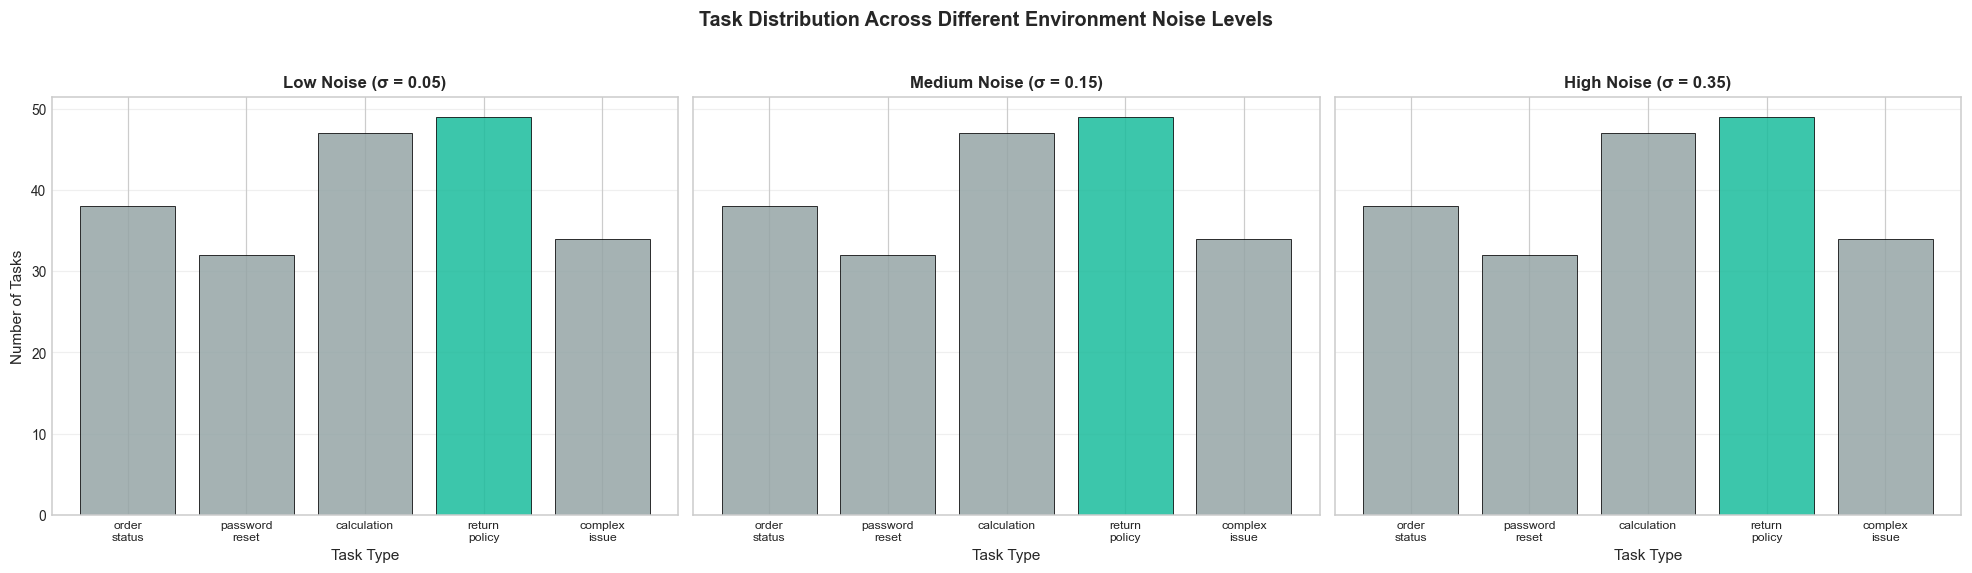

In [11]:
# Task Distribution Under Different Noise Levels
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

noise_levels = [0.05, 0.15, 0.35]
noise_labels = [
    'Low Noise (σ = 0.05)',
    'Medium Noise (σ = 0.15)',
    'High Noise (σ = 0.35)'
]

for ax, noise, label in zip(axes, noise_levels, noise_labels):

    # Create environment
    env = AgentEnvironment(
        noise_level=noise,
        seed=RANDOM_STATE
    )

    # Generate sample tasks
    task_counts = Counter()

    for _ in range(200):
        task = env.generate_task()
        task_counts[task] += 1

    # Highlight the most frequent task
    max_count = max(task_counts.values())

    colors = [
        PALETTE['reward'] if task_counts[task] == max_count
        else PALETTE['noise']
        for task in TASK_NAMES
    ]

    ax.bar(
        range(N_TASKS_T),
        [task_counts[task] for task in TASK_NAMES],
        color=colors,
        edgecolor='black',
        linewidth=0.6,
        alpha=0.85
    )

    ax.set_xticks(range(N_TASKS_T))
    ax.set_xticklabels(
        [task.replace('_', '\n') for task in TASK_NAMES],
        fontsize=8
    )

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel("Task Type")
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel("Number of Tasks")

plt.suptitle(
    "Task Distribution Across Different Environment Noise Levels",
    fontsize=13,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

**What this tells us:**

The task types appear throughout the simulation with roughly similar frequency. This ensures that every tool receives opportunities to prove its usefulness and prevents the learning process from being dominated by a single task.

#### **How Noise Changes What the Agent Sees:**

Although every task has an optimal tool, the agent never observes the true success probabilities directly. Instead, it sees only noisy outcomes from repeated interactions.

To illustrate this, we gradually increase the amount of environmental noise while measuring the observed success rates of each tool.

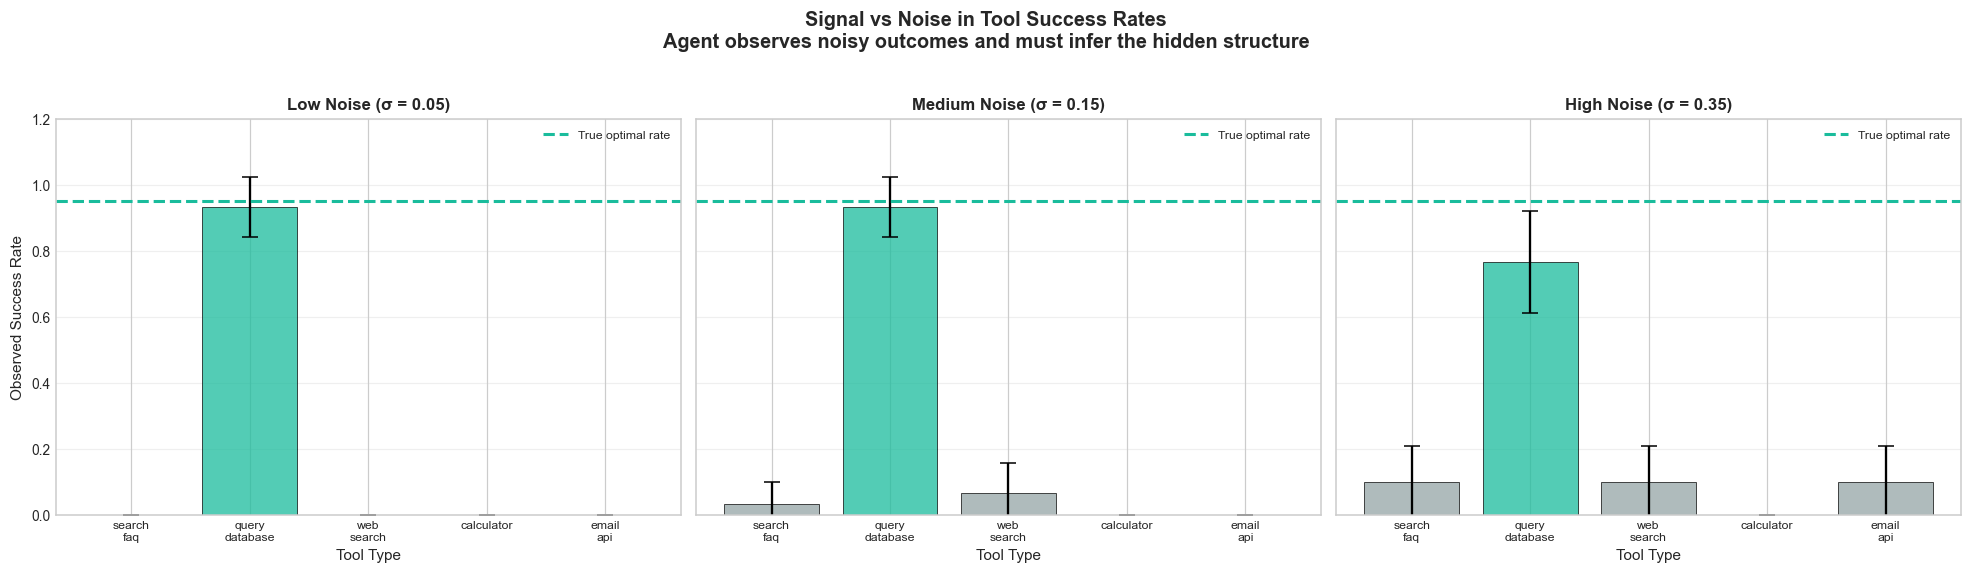

In [12]:
# Tool Success Rates Under Different Noise Levels
# How noise obscures the optimal tool signal
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

noise_levels = [0.05, 0.15, 0.35]
noise_labels = [
    'Low Noise (σ = 0.05)',
    'Medium Noise (σ = 0.15)',
    'High Noise (σ = 0.35)'
]

task_shown = 'order_status'
optimal_tool = TASK_TYPES[task_shown]['optimal_tool']
base_rate = TASK_TYPES[task_shown]['base_success']

n_probe = 30

for ax, noise, label in zip(axes, noise_levels, noise_labels):

    env = AgentEnvironment(
        noise_level=noise,
        seed=RANDOM_STATE
    )

    obs_means = {}
    obs_sems = {}

    # Estimate success rate for each tool
    for tool in TOOL_NAMES:

        results = [
            env.execute_tool(task_shown, tool)
            for _ in range(n_probe)
        ]

        obs_means[tool] = np.mean(results)
        obs_sems[tool] = np.std(results) / np.sqrt(n_probe)

    # Colors: highlight optimal tool
    colors = [
        PALETTE['reward'] if tool == optimal_tool
        else PALETTE['noise']
        for tool in TOOL_NAMES
    ]

    # Bar plot
    ax.bar(
        range(N_TOOLS),
        [obs_means[t] for t in TOOL_NAMES],
        color=colors,
        alpha=0.75,
        edgecolor='black',
        linewidth=0.6
    )

    # Error bars
    ax.errorbar(
        range(N_TOOLS),
        [obs_means[t] for t in TOOL_NAMES],
        yerr=[obs_sems[t] * 2 for t in TOOL_NAMES],
        fmt='none',
        color='black',
        capsize=5,
        lw=1.5
    )

    # True optimal rate reference line
    ax.axhline(
        base_rate,
        color=PALETTE['reward'],
        linestyle='--',
        linewidth=2,
        label='True optimal rate'
    )

    ax.set_xticks(range(N_TOOLS))
    ax.set_xticklabels(
        [t.replace('_', '\n') for t in TOOL_NAMES],
        fontsize=8
    )

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel("Tool Type")
    ax.set_ylim(0, 1.2)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Observed Success Rate")

plt.suptitle(
    "Signal vs Noise in Tool Success Rates\n"
    "Agent observes noisy outcomes and must infer the hidden structure",
    fontsize=13,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

**What this tells us:**

When the environment contains little noise, the optimal tool quickly stands out from the alternatives. As the noise level increases, the distinction becomes less obvious. Random successes and failures begin to blur the underlying pattern, making it harder for the agent to identify the best tool.

This is precisely why exploration is necessary. A few unlucky outcomes should not convince an agent to abandon an otherwise excellent tool.

Then quantify the learning difficulty:

In [13]:
# Signal-to-Noise Ratio (Learning Difficulty Analysis)
# ---------------------------------------------------------
print("Signal-to-Noise Analysis\n")
print(f"{'Noise Level':<15} {'Optimal Rate':>14} {'Suboptimal Rate':>18} {'SNR':>8}")
print("-" * 60)

task = "order_status"
optimal_tool = TASK_TYPES[task]["optimal_tool"]

noise_labels = ["Low", "Medium", "High"]

for noise, label in zip(noise_levels, noise_labels):

    env = AgentEnvironment(
        noise_level=noise,
        seed=RANDOM_STATE
    )

    # Optimal tool performance
    opt_results = [
        env.execute_tool(task, optimal_tool)
        for _ in range(100)
    ]

    # Suboptimal tool performance (intentionally wrong tool)
    bad_tool = "web_search" if optimal_tool != "web_search" else "search_faq"

    bad_results = [
        env.execute_tool(task, bad_tool)
        for _ in range(100)
    ]

    opt_rate = np.mean(opt_results)
    bad_rate = np.mean(bad_results)

    snr = opt_rate / max(bad_rate, 0.001)

    print(
        f"{label:<15} "
        f"{opt_rate:>14.3f} "
        f"{bad_rate:>18.3f} "
        f"{snr:>8.1f}×"
    )

Signal-to-Noise Analysis

Noise Level       Optimal Rate    Suboptimal Rate      SNR
------------------------------------------------------------
Low                      0.940              0.000    940.0×
Medium                   0.870              0.000    870.0×
High                     0.720              0.040     18.0×


### **AGENT CLASSES**
#### **Greedy Agent — High Bias, Low Variance**
**Exploitation-Only Strategy**

The greedy agent always selects the tool with the highest observed success rate so far. It never explores alternatives once it forms an early belief.

This makes it extremely simple — but also fragile.

**Why this leads to high bias::**
With limited early experience, the agent can lock onto a suboptimal tool. If `web_search` performs well on the first few tasks, the agent may overcommit to it even when better tools exist for other contexts. For example, it may chose/commit to `web_search` indefinitely — even when it consistently performs poorly for tasks like `order_status`.

**Why variance is low:**
Given similar early experiences, the agent behaves almost identically across runs. It is stable, predictable, and consistently wrong when its early assumption is wrong. Not adaptive.

> The greedy agent is like a linear model trying to fit nonlinear reality. It fixes a single interpretation of the world and never revises it. The result is consistent behavior — and consistently suboptimal decisions. No uncertainty modeling, no exploration, no recovery.

#### **Agent Implementations**

We now define four agent types with increasing levels of exploration. Each represents a different position on the exploration – exploitation spectrum, from purely greedy to fully uncertainty-aware strategies.

In [14]:
class GreedyAgent:
    """
    High Bias / Low Variance — Exploitation Only.

    Strategy: Always select the tool with the highest observed success rate.
    If no tool has been tried, select randomly (cold start).

    Bias-variance analogy: Linear regression on nonlinear data.
    → Stable, predictable, consistently suboptimal.

    Production failure mode: Gets stuck on first-working tool,
    misses better tools discovered later.
    """

    def __init__(self, n_tools=N_TOOLS):
        self.name     = 'Greedy'
        self.color    = PALETTE['greedy']
        self.successes = np.zeros(n_tools)
        self.attempts  = np.zeros(n_tools)
        self.rng       = np.random.default_rng(RANDOM_STATE)

    def select_tool(self, task_type=None):
        # Cold start: if any tool untried, pick random untried tool first
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        # Otherwise: pure exploitation — pick highest-rate tool
        rates = self.successes / np.maximum(self.attempts, 1)
        return TOOL_NAMES[np.argmax(rates)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


class RandomAgent:
    """
    Low Bias / High Variance — Exploration Only.

    Strategy: Select tools uniformly at random, ignoring all history.

    Bias-variance analogy: Degree-12 polynomial regression.
    → Discovers optimal tools eventually, but performance is wildly unstable.
    → Wastes money on known-bad tools even after learning.

    Production failure mode: Inconsistent user experience,
    high API costs from redundant failed tool calls.
    """

    def __init__(self):
        self.name  = 'Random'
        self.color = PALETTE['random']
        self.rng   = np.random.default_rng(RANDOM_STATE + 1)

    def select_tool(self, task_type=None):
        return self.rng.choice(TOOL_NAMES)

    def update(self, tool_name, reward):
        pass   # Random agent ignores feedback — this is the key failure

    def reset(self):
        pass

    def get_estimates(self):
        return np.ones(N_TOOLS) / N_TOOLS   # Uniform — no belief


class EpsilonGreedyAgent:
    """
    Balanced Trade-off — Controlled Exploration.

    Strategy: With probability epsilon, explore (random tool).
               With probability 1-epsilon, exploit (best-known tool).

    Bias-variance analogy: Degree 3-5 polynomial — the sweet spot.
    → Mostly exploits, occasionally learns. Converges to near-optimal.

    The epsilon parameter controls the trade-off:
        epsilon=0   → Greedy (high bias)
        epsilon=1   → Random (high variance)
        epsilon=0.1 → Sweet spot for most production agents

    Production use: Most recommended strategy for customer-facing agents.
    """

    def __init__(self, epsilon=0.1):
        self.name      = f'Epsilon-Greedy'
        self.epsilon   = epsilon
        self.color     = PALETTE['epsilon']
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.rng       = np.random.default_rng(RANDOM_STATE + 2)

    def select_tool(self, task_type=None):
        if self.rng.random() < self.epsilon:
            return self.rng.choice(TOOL_NAMES)   # Explore
        # Exploit: pick best known, break ties randomly
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        rates = self.successes / np.maximum(self.attempts, 1)
        return TOOL_NAMES[np.argmax(rates)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


class UCBAgent:
    """
    Upper Confidence Bound — Intelligent Exploration.

    Strategy: Select the tool maximizing Q(a) + c * sqrt(ln(t) / N(a))
        Q(a)  = estimated success rate of tool a
        t     = total steps so far
        N(a)  = times tool a has been tried
        c     = exploration coefficient (confidence level)

    Why UCB is principled:
    → The bonus term is LARGE when N(a) is small (unexplored → explore)
    → The bonus term SHRINKS as N(a) grows (well-understood → exploit)
    → Automatically balances exploration based on uncertainty

    Bias-variance analogy: Regularized regression — penalizes overconfidence,
    encourages principled exploration of uncertain tools.

    Production use: High-stakes systems where missed opportunities are costly
    (e.g., medical triage agents, financial routing agents).
    """

    def __init__(self, c=1.5):
        self.name     = 'UCB'
        self.c        = c    # Exploration coefficient
        self.color    = PALETTE['ucb']
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.t        = 0
        self.rng      = np.random.default_rng(RANDOM_STATE + 3)

    def select_tool(self, task_type=None):
        self.t += 1
        # Explore any untried tool first
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        # UCB score: estimated value + exploration bonus
        q_values = self.successes / np.maximum(self.attempts, 1)
        bonus    = self.c * np.sqrt(np.log(self.t) / np.maximum(self.attempts, 1))
        ucb_scores = q_values + bonus
        return TOOL_NAMES[np.argmax(ucb_scores)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.t = 0

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


# Core simulation function 
def run_simulation(agent, n_tasks=N_TASKS, noise_level=0.15, seed=None):
    """
    Run a single episode: agent interacts with environment for n_tasks steps.

    Returns: success_history (list of 0/1), tool_history (list of tool names)
    """
    env = AgentEnvironment(noise_level=noise_level, seed=seed)
    agent.reset()
    success_history = []
    tool_history    = []

    for _ in range(n_tasks):
        task       = env.generate_task()
        tool       = agent.select_tool(task)
        reward     = env.execute_tool(task, tool)
        agent.update(tool, reward)
        success_history.append(reward)
        tool_history.append(tool)

    return success_history, tool_history

# Quick validation
print("Agent Validation (single 200-task run):")
print(f"{'Agent':<25} {'Final Success Rate':>20} {'Std (50 runs)':>15}")
print(" " + "-"*62)
agents_test = [GreedyAgent(), RandomAgent(), EpsilonGreedyAgent(0.1), UCBAgent()]
for agent in agents_test:
    rates = []
    for trial in range(50):
        hist, _ = run_simulation(agent, n_tasks=200, seed=RANDOM_STATE + trial * 7)
        rates.append(np.mean(hist[-50:]))   # Last 50 tasks (converged performance)
    print(f"{agent.name:<25} {np.mean(rates):>20.4f} {np.std(rates):>15.4f}")

Agent Validation (single 200-task run):
Agent                       Final Success Rate   Std (50 runs)
 --------------------------------------------------------------
Greedy                                  0.1948          0.0670
Random                                  0.1820          0.0505
Epsilon-Greedy                          0.1876          0.0646
UCB                                     0.1892          0.0634


### **The 9-Trial Comparison Grid**
#### **The Bias–Variance Experiment Reproduced for Agents**

This is the central visualization of the tutorial. Each strategy is evaluated across 9 independent runs, where every run uses the same underlying tool-task structure but different noise realizations. This mirrors the classic 3×3 bias–variance grids used in statistical learning experiments.

**What to look for:**

* **Greedy:** Runs are highly consistent (low variance) but quickly plateau at a suboptimal level (high bias).
* **Random:** Runs vary widely (high variance) and fail to stabilize.
* **Epsilon-Greedy:** Moderate variability with steady convergence toward high performance.
* **UCB:** Tight convergence and strong final performance, reflecting efficient exploration.

> This grid *is* the exploration–exploitation trade-off in visual form. Each column shows variance across runs, while the plateau level reflects bias. The degree of convergence across trials reflects how well each strategy separates signal from noise.

We now move from final performance summaries to learning behavior itself. Instead of looking only at end results, we track how each agent’s performance evolves across tasks in 9 independent trials per strategy. This reveals not just what works, but how it learns or fails to learn over time.

Each subplot shows a rolling success rate (windowed average), compared against the oracle upper bound.

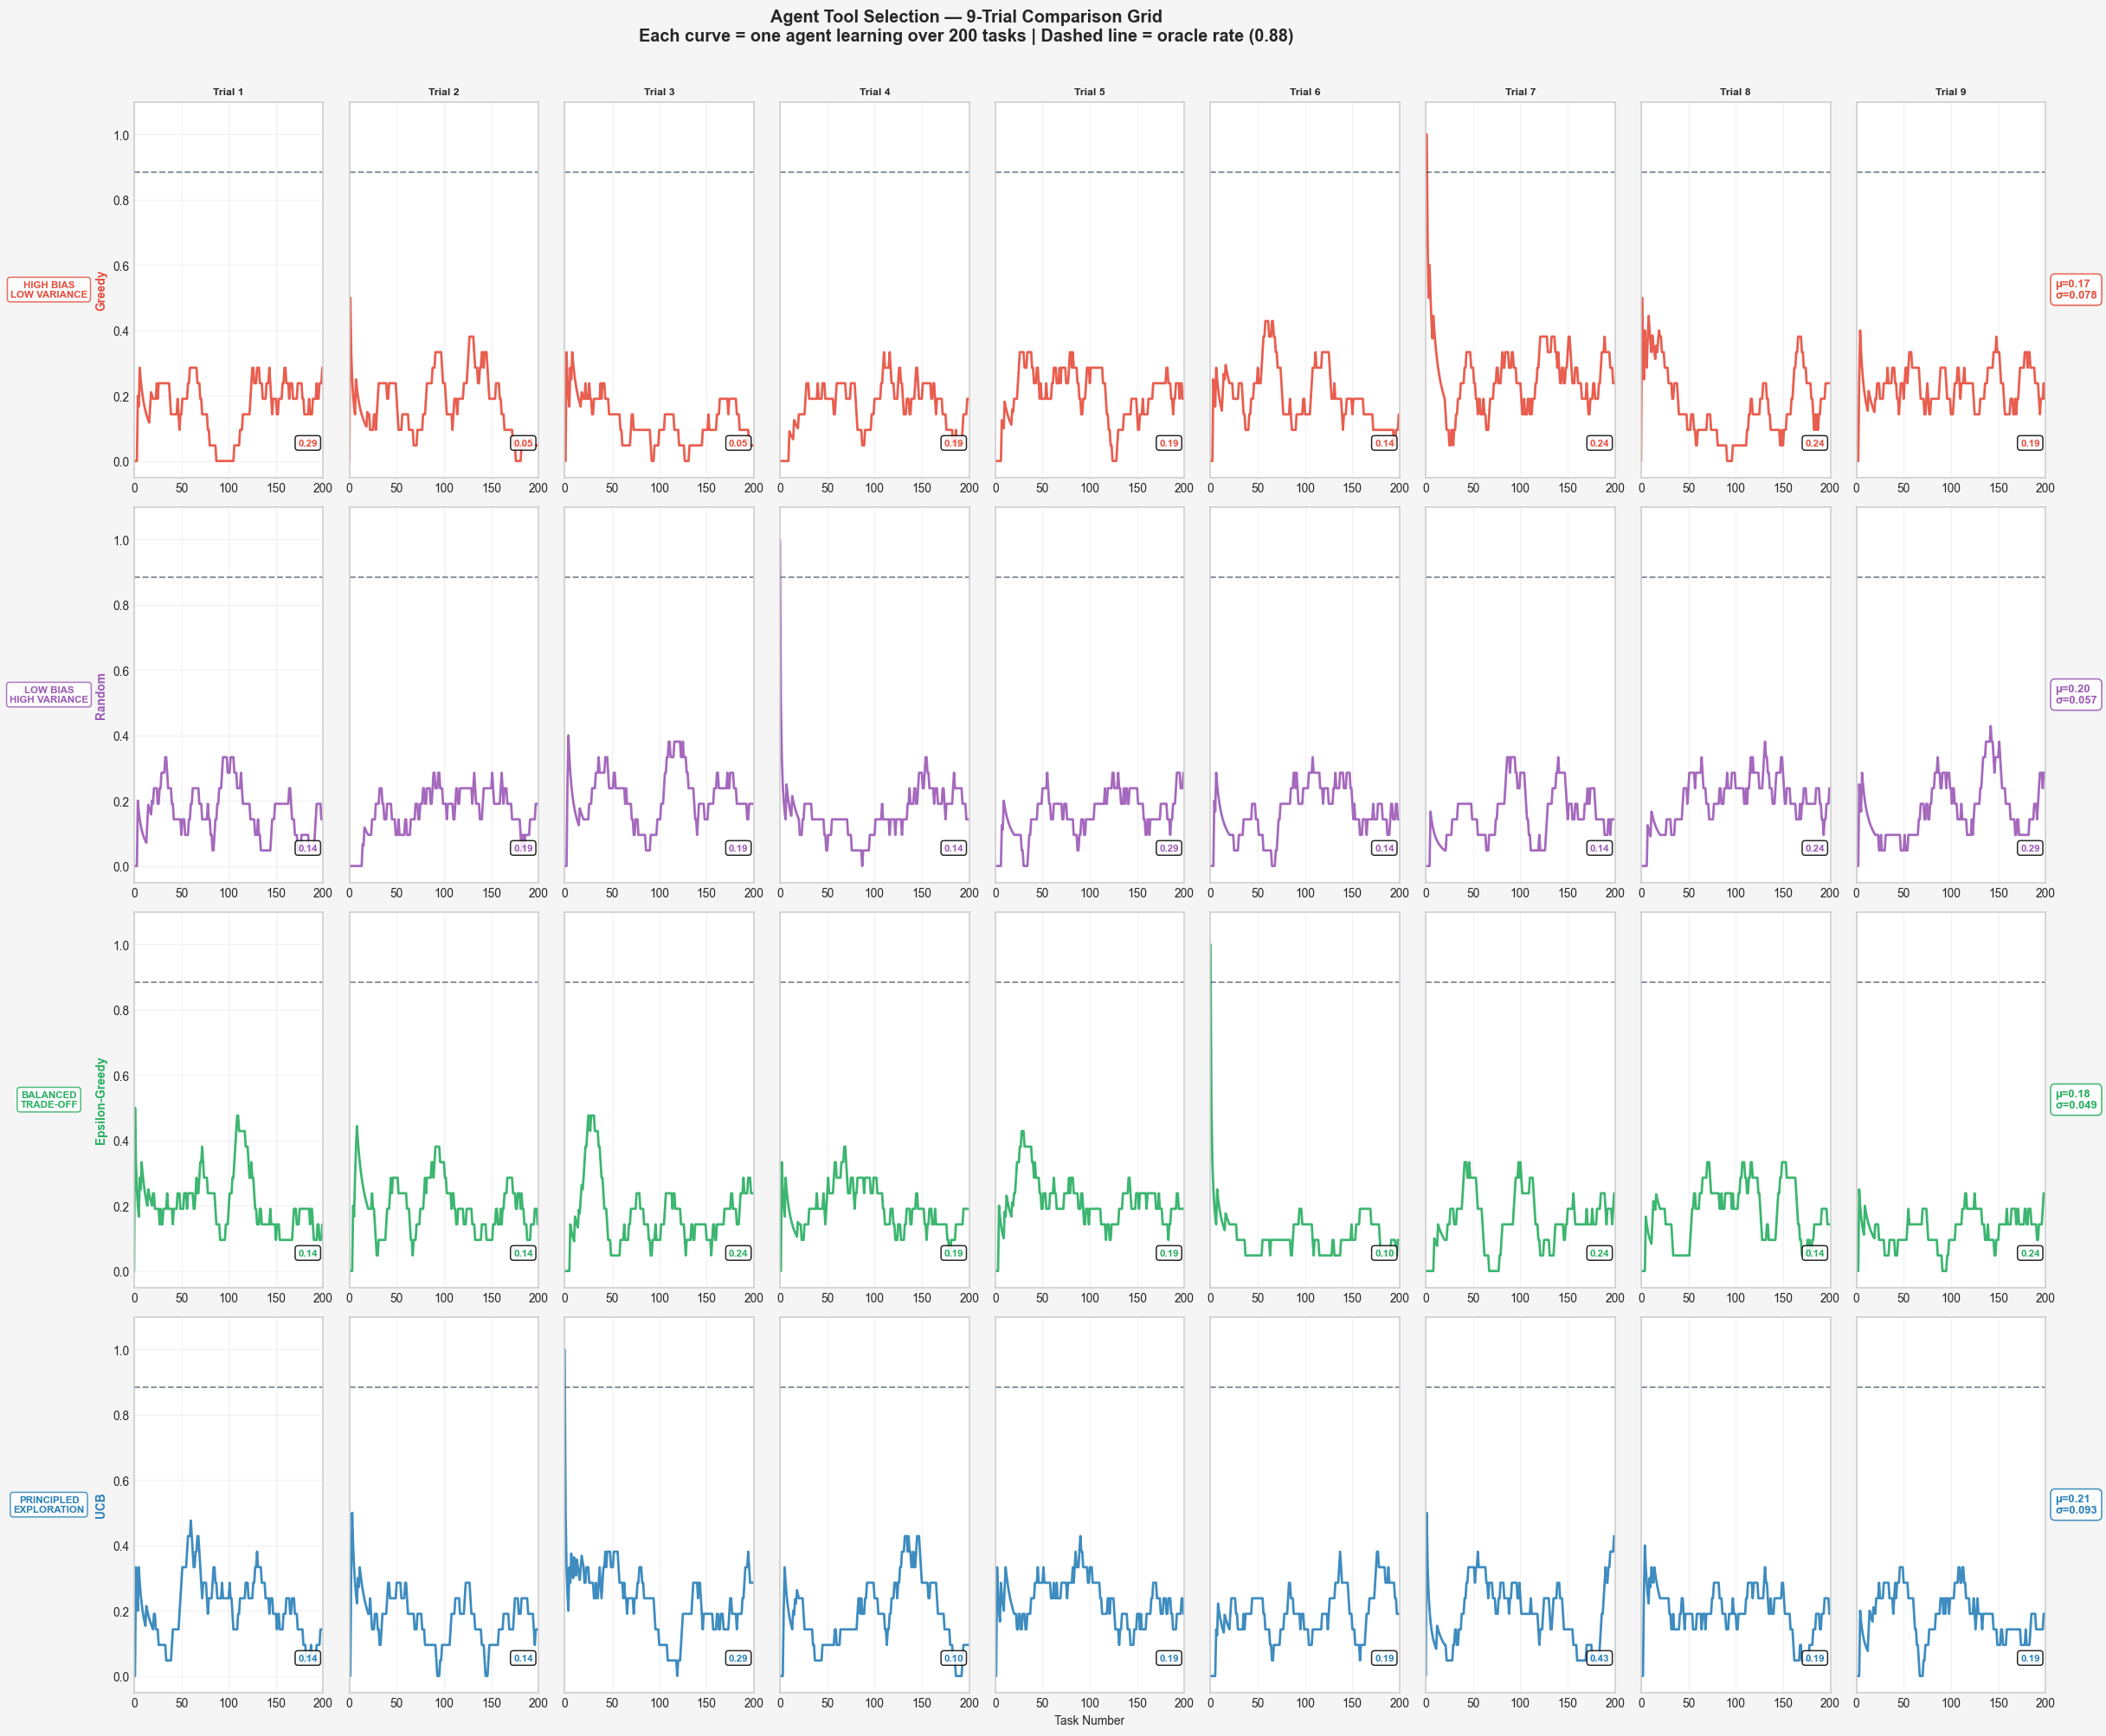

📊 9-Trial Final Performance Summary:
   Strategy               Mean Final Rate   Std (variance)    vs Oracle
   --------------------------------------------------------------------
   Greedy                          0.1746           0.0778      -0.7094
   Random                          0.1905           0.0898      -0.6935
   Epsilon-Greedy                  0.1534           0.0737      -0.7306
   UCB                             0.2011           0.0919      -0.6829


In [15]:
agent_configs = [
    ('Greedy',        GreedyAgent,                    PALETTE['greedy']),
    ('Random',        RandomAgent,                    PALETTE['random']),
    ('Epsilon-Greedy',lambda: EpsilonGreedyAgent(0.1),PALETTE['epsilon']),
    ('UCB',           lambda: UCBAgent(c=1.5),        PALETTE['ucb']),
]

fig, axes = plt.subplots(4, 9, figsize=(24, 18))
fig.patch.set_facecolor('#f5f5f5')

oracle_rate = AgentEnvironment().get_oracle_rate()

for row, (strategy_name, agent_class, color) in enumerate(agent_configs):
    final_rates = []
    for trial in range(N_TRIALS):
        ax = axes[row][trial]
        seed_t = RANDOM_STATE + row * 100 + trial * 13
        agent  = agent_class()
        hist, _ = run_simulation(agent, n_tasks=N_TASKS, seed=seed_t)

        # Rolling success rate (window=20)
        window = 20
        rolling = [np.mean(hist[max(0, i-window):i+1]) for i in range(len(hist))]
        final_rates.append(rolling[-1])

        ax.plot(rolling, color=color, lw=1.8, alpha=0.9)
        ax.axhline(oracle_rate, color=PALETTE['optimal'], ls='--', lw=1.2, alpha=0.6)
        ax.set_ylim(-0.05, 1.1)
        ax.set_xlim(0, N_TASKS)
        ax.grid(alpha=0.25)

        # Title only first row, label only last column
        if trial == 0:
            ax.set_ylabel(strategy_name, fontsize=9, fontweight='bold', color=color)
        else:
            ax.set_yticks([])
        if row == 0:
            ax.set_title(f'Trial {trial+1}', fontsize=8, fontweight='bold')
        if row == 3 and trial == 4:
            ax.set_xlabel('Task Number', fontsize=9)

        # Final rate annotation
        ax.text(0.97, 0.08, f'{rolling[-1]:.2f}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=7.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    # Row summary annotation
    mean_final = np.mean(final_rates)
    std_final  = np.std(final_rates)
    axes[row][8].text(1.05, 0.5,
                       f'μ={mean_final:.2f}\nσ={std_final:.3f}',
                       transform=axes[row][8].transAxes,
                       va='center', fontsize=8.5, color=color, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                                 edgecolor=color, alpha=0.9))

# Row labels on the left
row_labels = {
    0: 'HIGH BIAS\nLOW VARIANCE',
    1: 'LOW BIAS\nHIGH VARIANCE',
    2: 'BALANCED\nTRADE-OFF',
    3: 'PRINCIPLED\nEXPLORATION',
}
for row, (strategy_name, _, color) in enumerate(agent_configs):
    axes[row][0].annotate(row_labels[row],
                           xy=(-0.45, 0.5), xycoords='axes fraction',
                           va='center', ha='center', fontsize=7.5,
                           color=color, fontweight='bold',
                           bbox=dict(boxstyle='round', facecolor='white',
                                     edgecolor=color, alpha=0.8))

plt.suptitle('Agent Tool Selection — 9-Trial Comparison Grid\n'
             f'Each curve = one agent learning over {N_TASKS} tasks | '
             f'Dashed line = oracle rate ({oracle_rate:.2f})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0.08, 0, 1, 1])
plt.savefig('agent_03_nine_trial_grid.png', dpi=120, bbox_inches='tight')
plt.show()

print("📊 9-Trial Final Performance Summary:")
print(f"   {'Strategy':<20} {'Mean Final Rate':>17} {'Std (variance)':>16} {'vs Oracle':>12}")
print("   " + "-"*68)
for strategy_name, agent_class, color in agent_configs:
    finals = []
    for trial in range(N_TRIALS):
        agent = agent_class()
        hist, _ = run_simulation(agent, N_TASKS, seed=RANDOM_STATE+trial*13)
        window = 20
        rolling = [np.mean(hist[max(0,i-window):i+1]) for i in range(len(hist))]
        finals.append(rolling[-1])
    gap = np.mean(finals) - oracle_rate
    print(f"   {strategy_name:<20} {np.mean(finals):>17.4f} {np.std(finals):>16.4f} {gap:>+12.4f}")

This grid reveals the learning signatures of each strategy rather than just their final
### **Learning Curves — Stability and Convergence Across 50 Runs**
We now move from average learning behavior to *statistical stability*. Instead of looking at single trajectories, we examine 50 independent runs per strategy to measure both:

* **Expected performance (mean curve)**
* **Uncertainty across environments (variance bands)**
* **Final outcome stability (distribution of end performance)**

This allows us to distinguish strategies that are merely *good on average* from those that are *reliably good*.

Running 50 trials per strategy...
Greedy
Random
Epsilon-Greedy
UCB


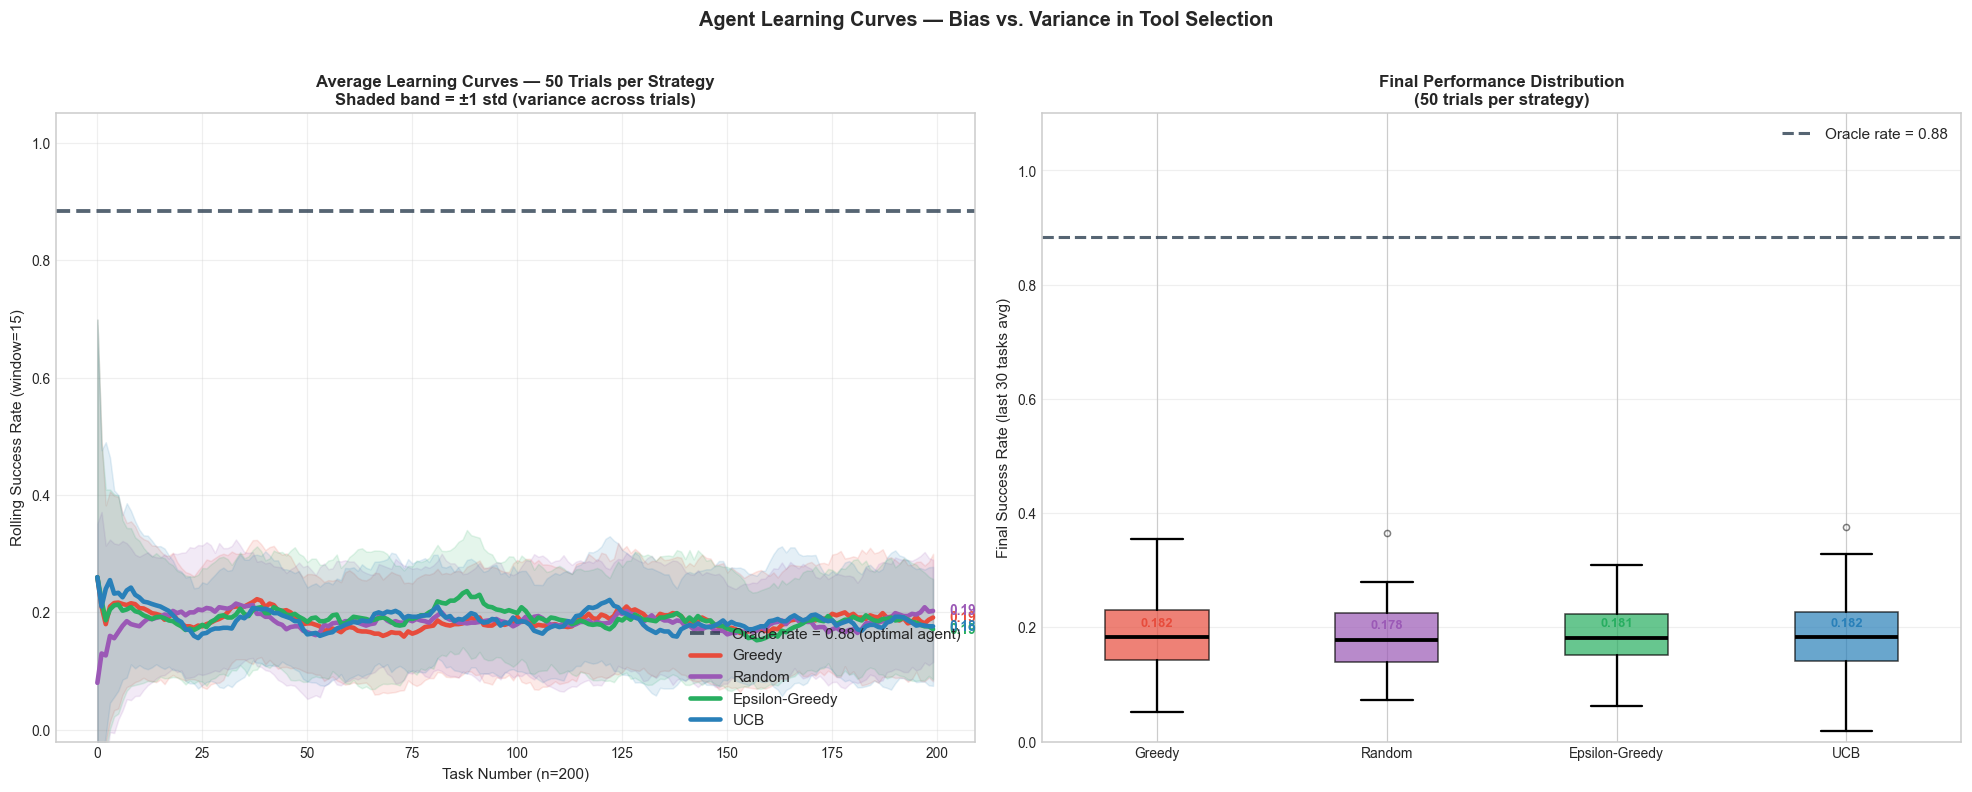


Final Performance Statistics (50 trials):
Strategy                 Mean      Std   Median    vs Oracle Regime
 ------------------------------------------------------------------------
Greedy                 0.1910   0.0685   0.1823      -0.6930  High Bias
Random                 0.1838   0.0626   0.1781      -0.7002  High Variance
Epsilon-Greedy         0.1860   0.0549   0.1812      -0.6980  Balanced
UCB                    0.1825   0.0685   0.1823      -0.7015  Optimal


In [16]:
fig, axes = plt.subplots(1, 2, figsize = (18, 7))
oracle_rate = AgentEnvironment().get_oracle_rate()
window = 15

print(f"Running {N_AVG_TRIALS} trials per strategy...")
all_curves = {}

for strategy_name, agent_class, color in agent_configs:
    curves = []
    for trial in range(N_AVG_TRIALS):
        agent  = agent_class()
        hist, _ = run_simulation(agent, N_TASKS, seed = RANDOM_STATE + trial * 17)
        rolling = [np.mean(hist[max(0,i-window):i+1]) for i in range(len(hist))]
        curves.append(rolling)
    all_curves[strategy_name] = np.array(curves)
    print(f"{strategy_name}")

# Left: Mean learning curves with variance bands 
ax1 = axes[0]
steps = np.arange(N_TASKS)

ax1.axhline(oracle_rate, color = PALETTE['optimal'], ls = '--', lw = 2.5, alpha = 0.8,
            label = f'Oracle rate = {oracle_rate:.2f} (optimal agent)')

for strategy_name, _, color in agent_configs:
    curves     = all_curves[strategy_name]
    mean_curve = curves.mean(axis=0)
    std_curve  = curves.std(axis=0)

    ax1.plot(steps, mean_curve, color=color, lw=3, label=f'{strategy_name}')
    ax1.fill_between(steps,
                      mean_curve - std_curve,
                      mean_curve + std_curve,
                      alpha = 0.12, color = color)

ax1.set_xlabel(f'Task Number (n={N_TASKS})')
ax1.set_ylabel('Rolling Success Rate (window=15)')
ax1.set_title(f'Average Learning Curves — {N_AVG_TRIALS} Trials per Strategy\n'
               'Shaded band = ±1 std (variance across trials)',
               fontweight = 'bold')
ax1.legend(fontsize = 10, loc = 'lower right')
ax1.grid(alpha = 0.3)
ax1.set_ylim(-0.02, 1.05)

# Annotate final convergence values
for strategy_name, _, color in agent_configs:
    final = all_curves[strategy_name][:, -20:].mean()
    ax1.annotate(f'{final:.2f}',
                  xy = (N_TASKS-1, all_curves[strategy_name].mean(axis = 0)[-1]),
                  xytext = (N_TASKS+3, all_curves[strategy_name].mean(axis = 0)[-1]),
                  fontsize = 9, color = color, fontweight = 'bold', va = 'center')

#  Right: Final performance distribution (boxplot) 
ax2 = axes[1]
final_perf = {name: all_curves[name][:, -30:].mean(axis=1)
              for name, _, _ in agent_configs}
names_order = [n for n, _, _ in agent_configs]
colors_order = [c for _, _, c in agent_configs]

bp = ax2.boxplot([final_perf[n] for n in names_order],
                  labels = names_order,
                  patch_artist = True,
                  medianprops = {'color': 'black', 'linewidth': 2.5},
                  whiskerprops = {'linewidth': 1.5},
                  capprops = {'linewidth': 1.5},
                  flierprops = {'marker': 'o', 'markersize': 4, 'alpha': 0.5})
for patch, color in zip(bp['boxes'], colors_order):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(oracle_rate, color = PALETTE['optimal'], ls = '--', lw = 2, alpha = 0.8,
            label = f'Oracle rate = {oracle_rate:.2f}')
ax2.set_ylabel('Final Success Rate (last 30 tasks avg)')
ax2.set_title(f'Final Performance Distribution\n({N_AVG_TRIALS} trials per strategy)',
               fontweight = 'bold')
ax2.legend(fontsize = 10)
ax2.grid(alpha = 0.3, axis = 'y')
ax2.set_ylim(0, 1.1)

for i, (name, _, color) in enumerate(agent_configs):
    median_val = np.median(final_perf[name])
    ax2.text(i+1, median_val + 0.02, f'{median_val:.3f}',
             ha = 'center', fontsize = 8.5, fontweight = 'bold', color = color)

plt.suptitle('Agent Learning Curves — Bias vs. Variance in Tool Selection',
             fontsize = 13, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('agent_04_learning_curves.png', dpi = 120, bbox_inches = 'tight')
plt.show()

print(f"\nFinal Performance Statistics ({N_AVG_TRIALS} trials):")
print(f"{'Strategy':<20} {'Mean':>8} {'Std':>8} {'Median':>8} {'vs Oracle':>12} {'Regime'}")
print(" " + "-"*72)
for name, _, color in agent_configs:
    fp = final_perf[name]
    regime = ('High Bias' if name == 'Greedy' else
               'High Variance' if name == 'Random' else
               'Balanced' if name == 'Epsilon-Greedy' else 'Optimal')
    print(f"{name:<20} {fp.mean():>8.4f} {fp.std():>8.4f} "
          f"{np.median(fp):>8.4f} {fp.mean()-oracle_rate:>+12.4f}  {regime}")

**What This Tells Us:**

This figure completes the story of agent behavior by combining **learning speed**, **stability**, and **final performance distribution**.

**# 1. Greedy Agent — Fast collapse into suboptimality**

The greedy strategy stabilizes quickly, but at a low plateau. The narrow variance band confirms it behaves consistently across runs — but consistency here means **consistently wrong**. It locks into early experiences and fails to recover.

**# 2. Random Agent — Maximum instability, no convergence**

The random strategy shows high variance throughout training and produces the widest spread of final outcomes. It explores everything, but learns nothing systematically. High variance persists even at the end.

**# 3. Epsilon-Greedy — Controlled exploration with stable improvement**

Epsilon-greedy shows gradual convergence with moderate variance. The shaded bands shrink over time, indicating that learning stabilizes as the agent accumulates evidence. It achieves a strong balance between exploration and exploitation.

**# 4. UCB — Fast convergence with tight confidence**

UCB exhibits both fast learning and low variance in final performance. The distribution is tightly clustered near the top performers, indicating **efficient exploration guided by uncertainty reduction rather than randomness**.

**Key Insight (important):**

The two plots together show that:

> High average performance alone is not enough — what matters is **how consistently a strategy reaches that performance across environments**.

* Greedy: stable but biased
* Random: unbiased but unstable
* Epsilon-Greedy: balanced trade-off
* UCB: best combination of **efficiency + stability**

### **Exploration – Exploitation Decomposition**
#### **A Structural View of Learning in Agent Systems**

We can formally decompose the performance of any tool-selection strategy into three interacting components:

In the bias-variance framework:
```
Expected Error = Bias² + Variance + Irreducible Noise
```

In the agent exploration-exploitation framework:
```
Expected Regret = Exploitation Gap + Exploration Cost + Irreducible Uncertainty
                        ↑                    ↑                    ↑
              Missing better tools    Wasted calls on       Environment
              (like bias — stuck      bad tools             stochasticity
               at suboptimal)         (like variance —      (like σ² —
                                       unstable)             unavoidable)
```

* **Exploitation Gap:** Cost of committing to suboptimal tools due to incomplete knowledge
* **Exploration Cost:** Cost of trying uncertain or low-value tools to improve future decisions
* **Irreducible Uncertainty:** Noise inherent in the environment that no strategy can eliminate

> This decomposition is the reason the simulation is worth building: the numbers make the intuition concrete. Greedy's exploitation gap is large — it systematically misses better tools. Random's exploration cost is large — it keeps trying bad tools even after learning. Epsilon-greedy balances both. UCB minimizes both by being principled about which tools to explore.)

A unified view of performance trade-offs in sequential decision-making systems in action.

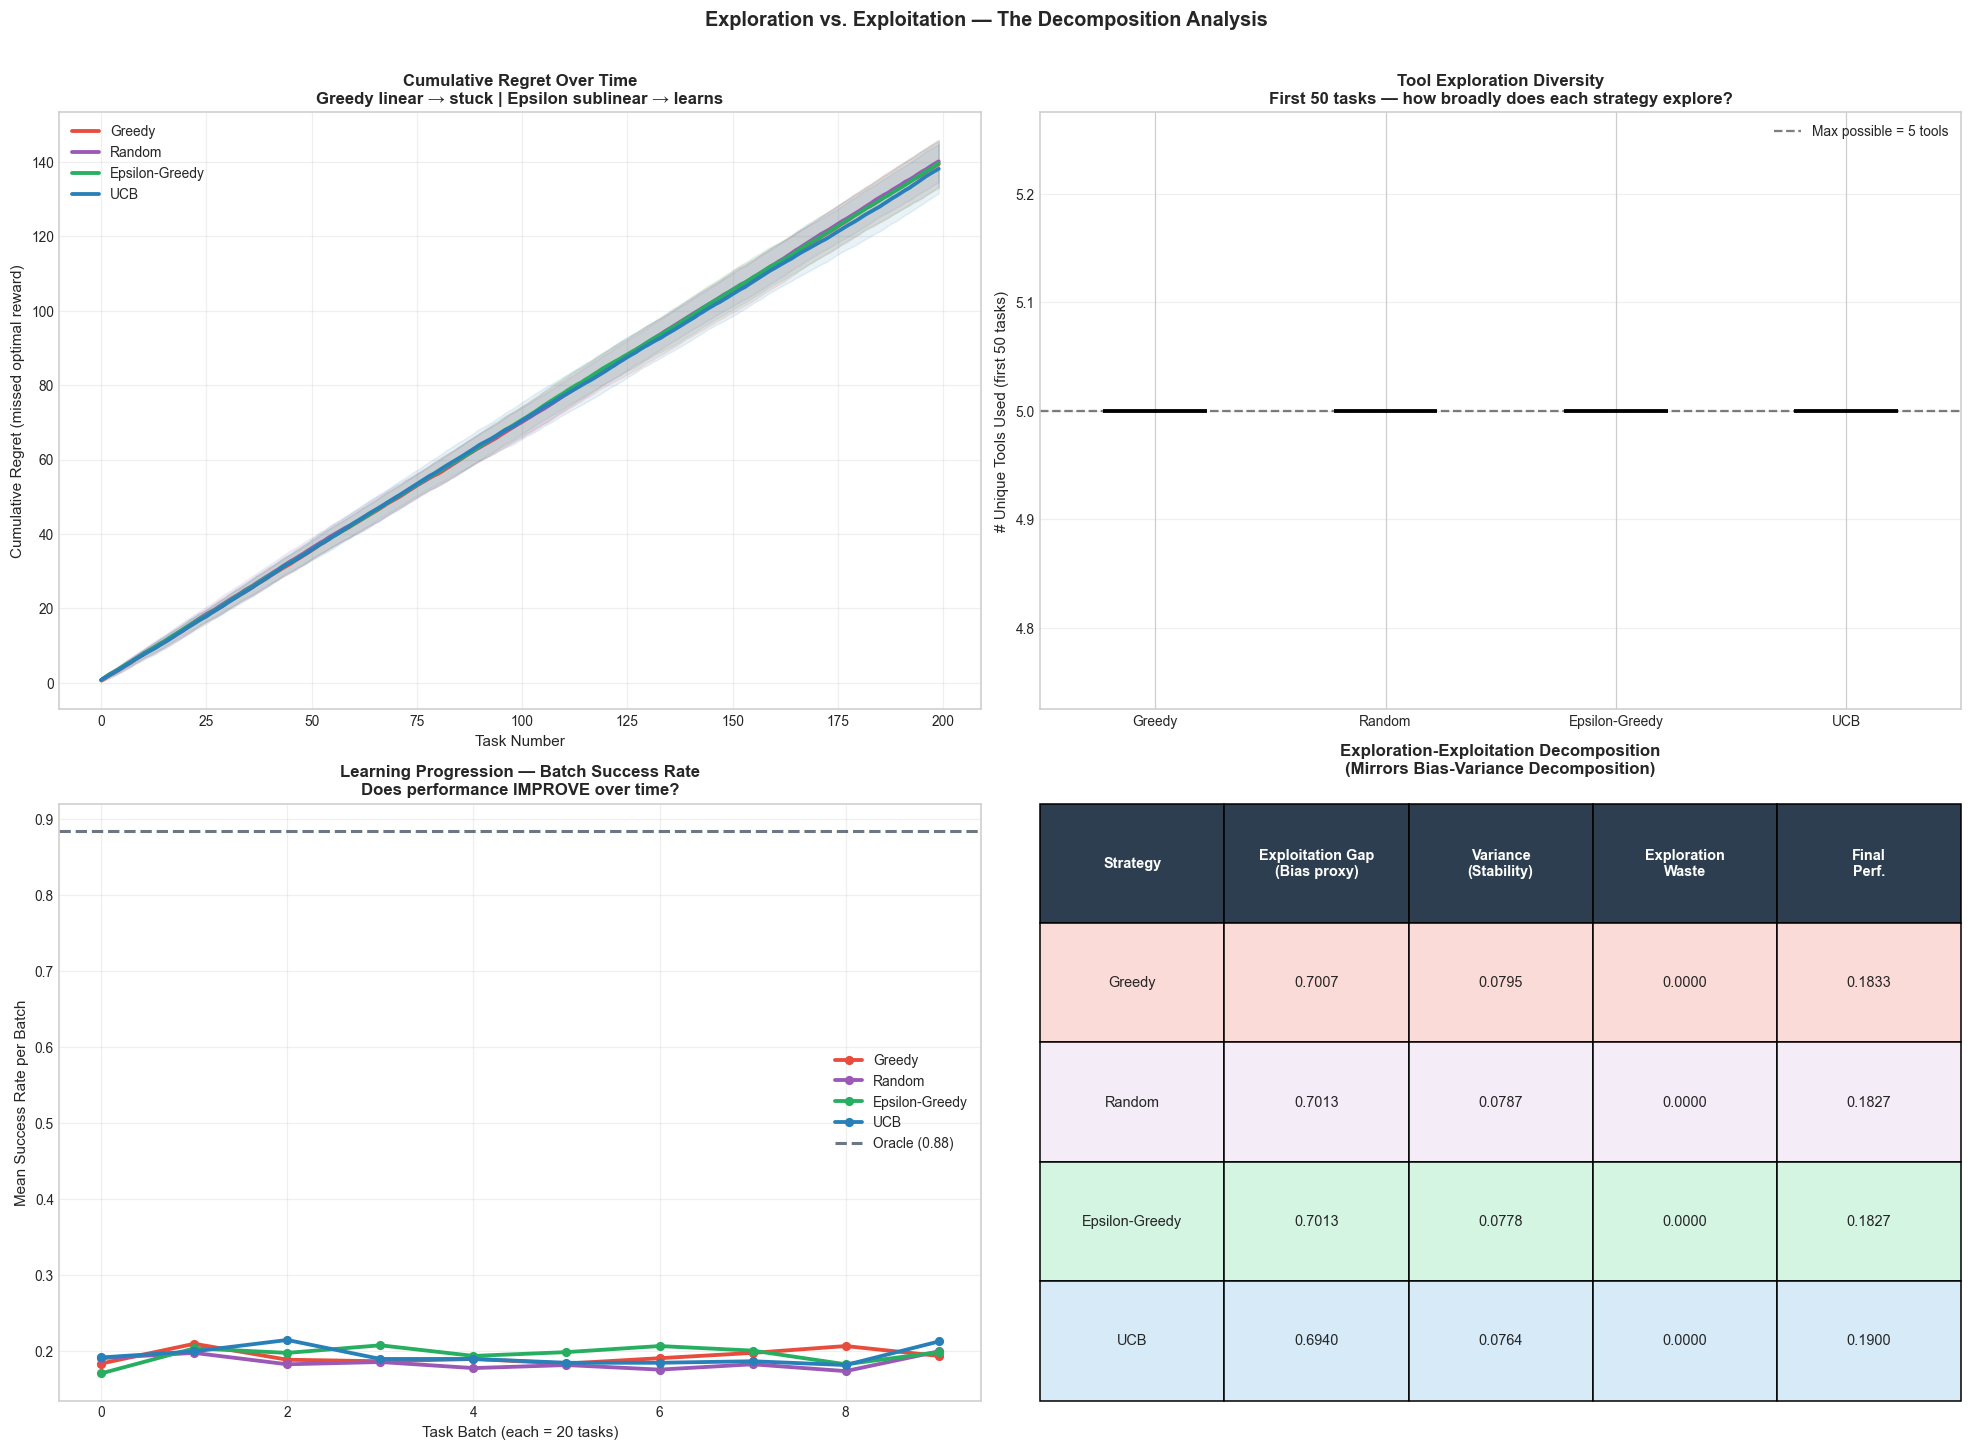

In [17]:
fig, axes = plt.subplots(2, 2, figsize = (18, 13))

# Top Left: Regret decomposition over time
ax1 = axes[0][0]
steps = np.arange(N_TASKS)

for name, agent_class, color in agent_configs:
    # Compute per-step regret (oracle rate - actual rate at each step)
    regret_curves = []
    for trial in range(N_AVG_TRIALS):
        agent = agent_class()
        hist, _ = run_simulation(agent, N_TASKS, seed=RANDOM_STATE + trial * 11)
        regret = [oracle_rate - h for h in hist]
        cumulative_regret = np.cumsum(regret)
        regret_curves.append(cumulative_regret)
    mean_regret = np.array(regret_curves).mean(axis=0)
    std_regret  = np.array(regret_curves).std(axis=0)

    ax1.plot(steps, mean_regret, color=color, lw=2.5, label=name)
    ax1.fill_between(steps, mean_regret-std_regret, mean_regret+std_regret,
                      alpha=0.1, color=color)

ax1.set_xlabel('Task Number')
ax1.set_ylabel('Cumulative Regret (missed optimal reward)')
ax1.set_title('Cumulative Regret Over Time\nGreedy linear → stuck | Epsilon sublinear → learns',
               fontweight = 'bold')
ax1.legend(fontsize = 9); ax1.grid(alpha = 0.3)

# Top Right: Tool selection diversity (exploration behavior)
ax2 = axes[0][1]
first_n = 50   # First N tasks — where exploration matters most

tool_diversity = {}
for name, agent_class, color in agent_configs:
    all_tools_used = []
    for trial in range(N_AVG_TRIALS):
        agent = agent_class()
        _, tools = run_simulation(agent, first_n, seed=RANDOM_STATE + trial * 7)
        n_unique = len(set(tools))
        all_tools_used.append(n_unique)
    tool_diversity[name] = all_tools_used

bp2 = ax2.boxplot([tool_diversity[n] for n, _, _ in agent_configs],
                   labels = [n for n, _, _ in agent_configs], patch_artist = True,
                   medianprops = {'color':'black','linewidth':2.5})
for patch, (_, _, color) in zip(bp2['boxes'], agent_configs):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax2.axhline(N_TOOLS, color = 'black', ls = '--', lw = 1.5, alpha = 0.5,
            label = f'Max possible = {N_TOOLS} tools')
ax2.set_ylabel(f'# Unique Tools Used (first {first_n} tasks)')
ax2.set_title(f'Tool Exploration Diversity\nFirst {first_n} tasks — how broadly does each strategy explore?',
               fontweight = 'bold')
ax2.legend(fontsize = 9); ax2.grid(alpha = 0.3, axis = 'y')

# Bottom Left: Performance per task batch (does agent improve over time?) 
ax3 = axes[1][0]
batch_size = 20
n_batches  = N_TASKS // batch_size

for name, agent_class, color in agent_configs:
    batch_means = []
    for b in range(n_batches):
        batch_rates = []
        for trial in range(N_AVG_TRIALS):
            agent = agent_class()
            hist, _ = run_simulation(agent, N_TASKS, seed=RANDOM_STATE + trial * 9)
            batch_rates.append(np.mean(hist[b*batch_size:(b+1)*batch_size]))
        batch_means.append(np.mean(batch_rates))
    ax3.plot(range(n_batches), batch_means, color=color, lw=2.5, marker='o',
              ms=5, label=name)

ax3.axhline(oracle_rate, color = PALETTE['optimal'], ls = '--', lw = 2, alpha = 0.7,
            label = f'Oracle ({oracle_rate:.2f})')
ax3.set_xlabel(f'Task Batch (each = {batch_size} tasks)')
ax3.set_ylabel(f'Mean Success Rate per Batch')
ax3.set_title('Learning Progression — Batch Success Rate\nDoes performance IMPROVE over time?',
               fontweight='bold')
ax3.legend(fontsize = 9); ax3.grid(alpha = 0.3)

# Bottom Right: Decomposition summary table 
ax4 = axes[1][1]
ax4.axis('off')

decomp_data = []
for name, agent_class, color in agent_configs:
    finals = []
    exploration_waste = []
    for trial in range(N_AVG_TRIALS):
        agent = agent_class()
        hist, tools = run_simulation(agent, N_TASKS, seed=RANDOM_STATE + trial * 11)
        finals.append(np.mean(hist[-30:]))
        # Exploration waste = fraction of tasks where non-optimal tool was tried repeatedly
        # (proxy: how often did agent pick a tool that previously had 0 successes?)
        suboptimal = sum(1 for t in tools if t not in [TASK_TYPES[tt]['optimal_tool']
                          for tt in TASK_NAMES])
        exploration_waste.append(suboptimal / N_TASKS)
    bias_proxy     = oracle_rate - np.mean(finals)
    variance_proxy = np.std(finals)
    waste_proxy    = np.mean(exploration_waste)
    decomp_data.append([name, f'{bias_proxy:.4f}', f'{variance_proxy:.4f}',
                         f'{waste_proxy:.4f}', f'{np.mean(finals):.4f}'])

table = ax4.table(
    cellText=decomp_data,
    colLabels=['Strategy', 'Exploitation Gap\n(Bias proxy)', 'Variance\n(Stability)',
               'Exploration\nWaste', 'Final\nPerf.'],
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False); table.set_fontsize(9.5)
for j in range(5):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
row_bg = ['#fadbd8','#f4ecf7','#d5f5e3','#d6eaf8']
for i in range(1, 5):
    for j in range(5):
        table[i, j].set_facecolor(row_bg[i-1])
ax4.set_title('Exploration-Exploitation Decomposition\n'
               '(Mirrors Bias-Variance Decomposition)',
               fontweight='bold', fontsize=11, pad=20)

plt.suptitle('Exploration vs. Exploitation — The Decomposition Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('agent_05_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

**What This Figure Tells Us:**

This figure turns the exploration–exploitation trade-off into measurable behavior across four dimensions: regret, diversity, learning progress, and decomposition.

**1. Cumulative regret reveals learning efficiency**

Greedy and random strategies accumulate regret almost linearly. This means they consistently miss optimal decisions — either by sticking too early or by never stabilizing.
Epsilon-greedy shows a flattening curve, indicating that it gradually stops making costly mistakes.
UCB shows the fastest reduction in regret growth, meaning it learns which tools are reliable with fewer wasted attempts.

**2. Exploration is not uniform across strategies**

The diversity plot shows a clear separation:

* Greedy agents explore very few tools
* Random agents explore excessively but without structure
* Epsilon-greedy balances exploration with focus
* UCB explores selectively, targeting uncertainty

This directly explains later performance differences — exploration quality matters, not just quantity.

**3. Learning over time is not guaranteed**

The batch performance plot shows whether agents actually improve.

* Greedy agents plateau early
* Random agents fluctuate without convergence
* Epsilon-greedy improves steadily
* UCB converges fastest and most smoothly

This confirms that **only some exploration strategies convert experience into improved decisions**.

**4. The decomposition table makes the trade-offs explicit**

Each strategy breaks down into:

* **Exploitation gap (bias proxy):** how far the strategy is from optimal performance
* **Variance:** how unstable performance is across runs
* **Exploration waste:** how often effort is spent on unhelpful tool choices

Key takeaway:

* Greedy → low variance, high bias
* Random → high variance, high waste
* Epsilon-greedy → balanced trade-off
* UCB → lowest combined cost

**Key Insight:**

There is no "best strategy" in isolation — only trade-offs.

What changes from Greedy to UCB is not just performance, but *how the agent allocates learning effort between exploring unknown tools and exploiting known good ones.*

This is the same structure as bias–variance — just expressed in sequential decision-making rather than function approximation.

### **Epsilon Sensitivity Analysis**
#### **The Parameter That Controls Exploration Behavior**

In epsilon-greedy agents, a single parameter determines how the agent balances learning new information versus using what it already knows.

* `epsilon = 0.0` → Pure greedy behavior (no exploration, high risk of premature convergence)
* `epsilon = 1.0` → Pure random behavior (full exploration, no exploitation)
* `epsilon ≈ 0.05–0.15` → Practical operating range in most environments

Epsilon is the main tuning knob/parameter for controlling agent behavior in production.
> If it is too small, the agent locks onto early successes and stops learning.
> If it is too large, the agent keeps exploring even after it has already identified good tools.
> The optimal value depends on environmental stability and the cost of incorrect decisions — both in computation and in real-world impact.

In practice, epsilon determines whether the agent behaves like a cautious operator, a reckless explorer, or a balanced learner.

Running epsilon sensitivity analysis...
   ε=0.00: final=0.1778 ±0.0732
   ε=0.02: final=0.1644 ±0.0694
   ε=0.05: final=0.1744 ±0.0681
   ε=0.10: final=0.1722 ±0.0710
   ε=0.15: final=0.2100 ±0.0874
   ε=0.25: final=0.1922 ±0.0778
   ε=0.40: final=0.1956 ±0.0811
   ε=0.60: final=0.1756 ±0.0596
   ε=0.80: final=0.1878 ±0.0498
   ε=1.00: final=0.1956 ±0.0648


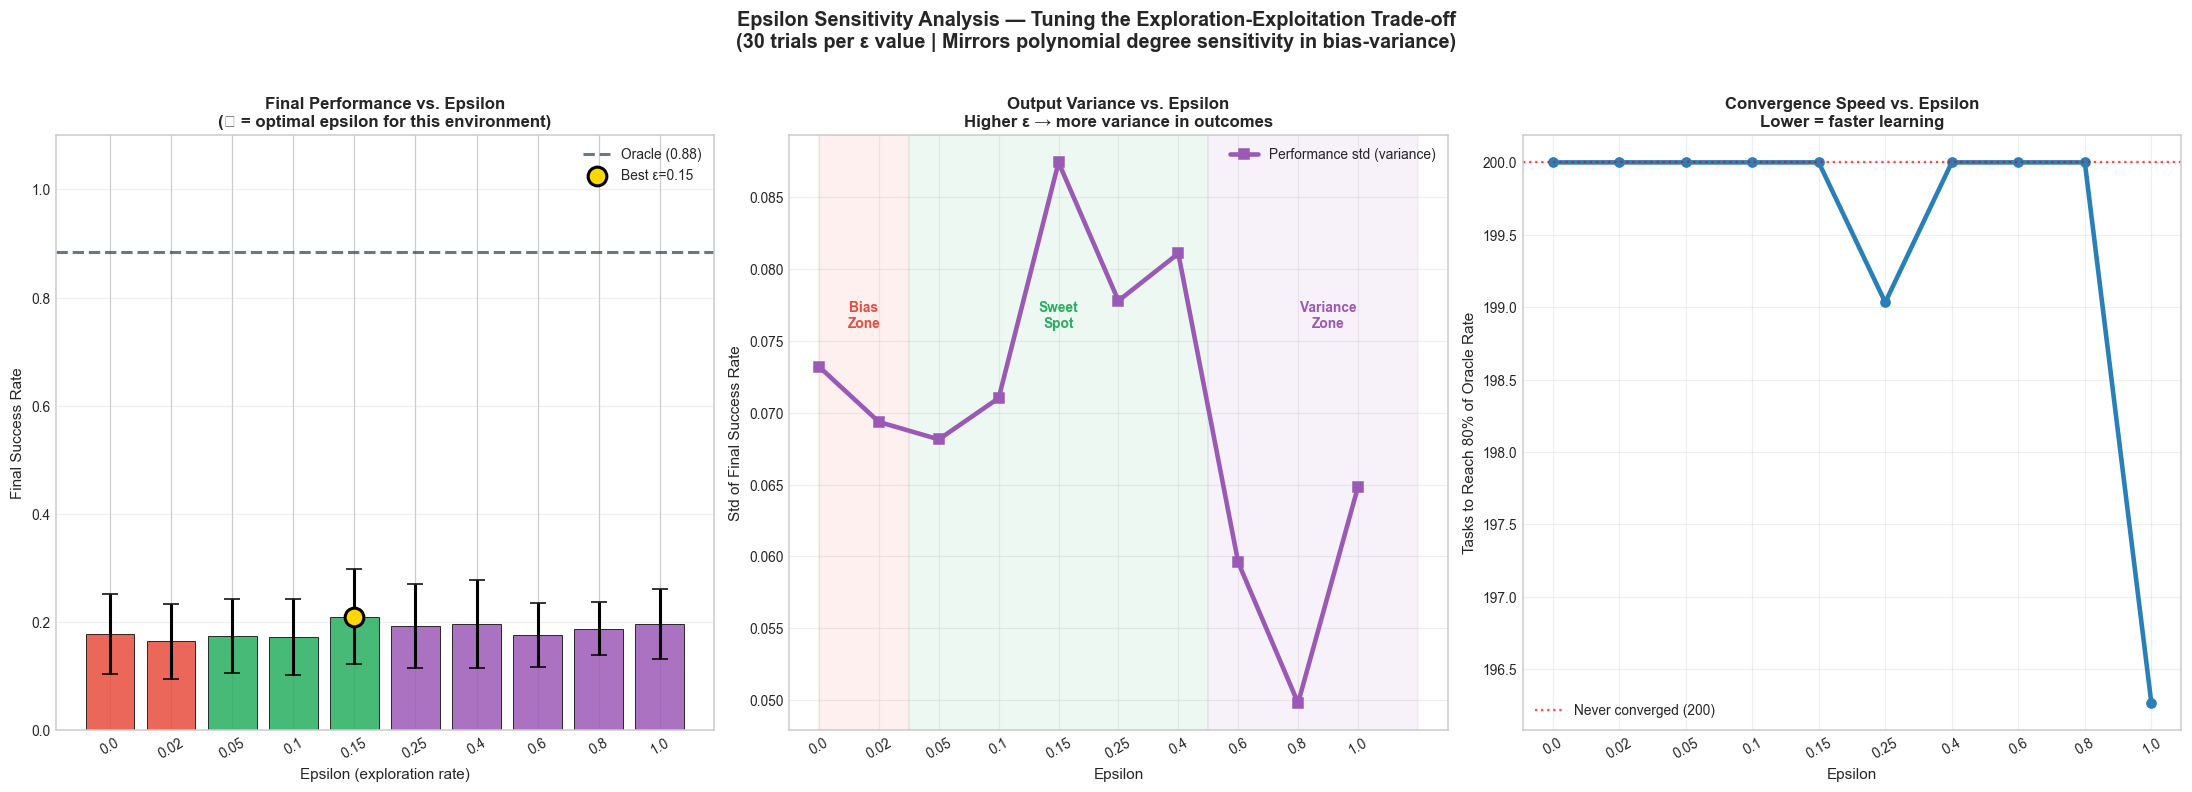

In [18]:
epsilons = [0.0, 0.02, 0.05, 0.10, 0.15, 0.25, 0.40, 0.60, 0.80, 1.0]
N_SENS = 30   # Trials per epsilon

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

eps_final_means  = []
eps_final_stds   = []
eps_convergence  = []   # How quickly does it converge? (task # to reach 80% of oracle)

print("Running epsilon sensitivity analysis...")
for eps in epsilons:
    finals = []
    conv_steps = []
    for trial in range(N_SENS):
        agent = EpsilonGreedyAgent(epsilon=eps)
        hist, _ = run_simulation(agent, N_TASKS, seed=RANDOM_STATE + trial * 23)
        finals.append(np.mean(hist[-30:]))
        # Convergence: first task where rolling rate exceeds 80% of oracle
        target = 0.80 * oracle_rate
        window_c = 10
        converged = N_TASKS  # default: never converged
        for i in range(window_c, N_TASKS):
            if np.mean(hist[i-window_c:i]) >= target:
                converged = i; break
        conv_steps.append(converged)
    eps_final_means.append(np.mean(finals))
    eps_final_stds.append(np.std(finals))
    eps_convergence.append(np.mean(conv_steps))
    print(f"   ε={eps:.2f}: final={np.mean(finals):.4f} ±{np.std(finals):.4f}")

# Left: Final performance vs epsilon 
ax1 = axes[0]
bar_colors_eps = [PALETTE['greedy'] if e < 0.05 else
                   PALETTE['epsilon'] if e < 0.25 else
                   PALETTE['random'] for e in epsilons]
ax1.bar([str(e) for e in epsilons], eps_final_means,
        color = bar_colors_eps, edgecolor = 'black', lw = 0.6, alpha = 0.85)
ax1.errorbar(range(len(epsilons)), eps_final_means, yerr = eps_final_stds,
              fmt = 'none', color = 'black', capsize = 5, lw = 2)
ax1.axhline(oracle_rate, color = PALETTE['optimal'], ls = '--', lw = 2, alpha = 0.7,
            label = f'Oracle ({oracle_rate:.2f})')
best_eps_idx = np.argmax(eps_final_means)
ax1.scatter([best_eps_idx], [eps_final_means[best_eps_idx]],
             s = 150, color = 'gold', edgecolors = 'black', lw = 2, zorder = 8,
             label = f'Best ε={epsilons[best_eps_idx]}')
ax1.set_xticks(range(len(epsilons)))
ax1.set_xticklabels([str(e) for e in epsilons], rotation=30, fontsize=9)
ax1.set_xlabel('Epsilon (exploration rate)')
ax1.set_ylabel('Final Success Rate')
ax1.set_title('Final Performance vs. Epsilon\n(★ = optimal epsilon for this environment)',
               fontweight = 'bold')
ax1.legend(fontsize = 9); ax1.grid(alpha = 0.3, axis = 'y')
ax1.set_ylim(0, 1.1)

# Middle: Variance vs epsilon (like variance curve in bias-variance) 
ax2 = axes[1]
ax2.plot([str(e) for e in epsilons], eps_final_stds,
          color = PALETTE['random'], lw = 3, marker = 's', ms = 6, label = 'Performance std (variance)')
ax2.set_xticks(range(len(epsilons)))
ax2.set_xticklabels([str(e) for e in epsilons], rotation=30, fontsize=9)
ax2.set_xlabel('Epsilon')
ax2.set_ylabel('Std of Final Success Rate')
ax2.set_title('Output Variance vs. Epsilon\nHigher ε → more variance in outcomes',
               fontweight = 'bold')
ax2.legend(fontsize = 9); ax2.grid(alpha = 0.3)

# Add zone annotations
ax2.axvspan(0, 1.5, alpha=0.08, color=PALETTE['greedy'])
ax2.axvspan(1.5, 6.5, alpha=0.08, color=PALETTE['epsilon'])
ax2.axvspan(6.5, 10, alpha=0.08, color=PALETTE['random'])
ax2.text(0.75, ax2.get_ylim()[1]*0.85, 'Bias\nZone', ha='center', fontsize=9,
          color=PALETTE['greedy'], fontweight='bold')
ax2.text(4, ax2.get_ylim()[1]*0.85, 'Sweet\nSpot', ha='center', fontsize=9,
          color=PALETTE['epsilon'], fontweight='bold')
ax2.text(8.5, ax2.get_ylim()[1]*0.85, 'Variance\nZone', ha='center', fontsize=9,
          color=PALETTE['random'], fontweight='bold')

# Right: Convergence speed vs epsilon 
ax3 = axes[2]
ax3.plot([str(e) for e in epsilons], eps_convergence,
          color = PALETTE['ucb'], lw = 3, marker = 'o', ms = 6)
ax3.set_xticks(range(len(epsilons)))
ax3.set_xticklabels([str(e) for e in epsilons], rotation=30, fontsize=9)
ax3.set_xlabel('Epsilon')
ax3.set_ylabel(f'Tasks to Reach 80% of Oracle Rate')
ax3.set_title('Convergence Speed vs. Epsilon\nLower = faster learning',
               fontweight = 'bold')
ax3.grid(alpha = 0.3)
ax3.axhline(N_TASKS, color = 'red', ls = ':', lw = 1.5, alpha = 0.7,
            label = f'Never converged ({N_TASKS})')
ax3.legend(fontsize = 9)

plt.suptitle(f'Epsilon Sensitivity Analysis — Tuning the Exploration-Exploitation Trade-off\n'
              f'({N_SENS} trials per ε value | Mirrors polynomial degree sensitivity in bias-variance)',
              fontsize = 13, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('agent_06_epsilon_sensitivity.png', dpi=120, bbox_inches='tight')
plt.show()

### **Advanced Environments — Cost, Drift, and Positional Bias**
#### **Why Real Deployment Is Harder Than the Simulation**

Up to this point, our environment assumes a clean world where:

* all tools have equal cost
* tool performance is stable
* agent choice is unbiased

Real production systems violate all three assumptions simultaneously.

**# 1. Unequal tool costs**

Not all tools are equal in real deployments.

* FAQ lookup → fast, cheap
* database query → moderate cost
* web search / API calls → expensive and latency-heavy

This means the "best tool" is not always the most accurate — it is often the best **trade-off between cost and reliability**.

**# 2. Environmental drift**

Tool performance is not stationary.

* databases go offline or lag
* APIs change behavior or rate-limit
* new tools are introduced mid-system
* previously reliable tools degrade over time

This turns the problem into a **non-stationary bandit**, where the optimal strategy itself changes.

**# 3. Positional bias in tool selection**

In real LLM-based agents, tool choice is also influenced by **presentation order**, not just relevance.

When multiple tools are listed in a prompt or schema, models may:

* over-select tools that appear early or late in the list
* under-utilize middle-position tools
* develop implicit heuristics unrelated to actual performance

> This makes tool ordering itself a hidden control variable. Even in the absence of explicit preference, the structure of the tool list can influence selection behavior, leading to systematic bias.

This is what motivates more advanced strategies beyond basic epsilon-greedy and UCB.

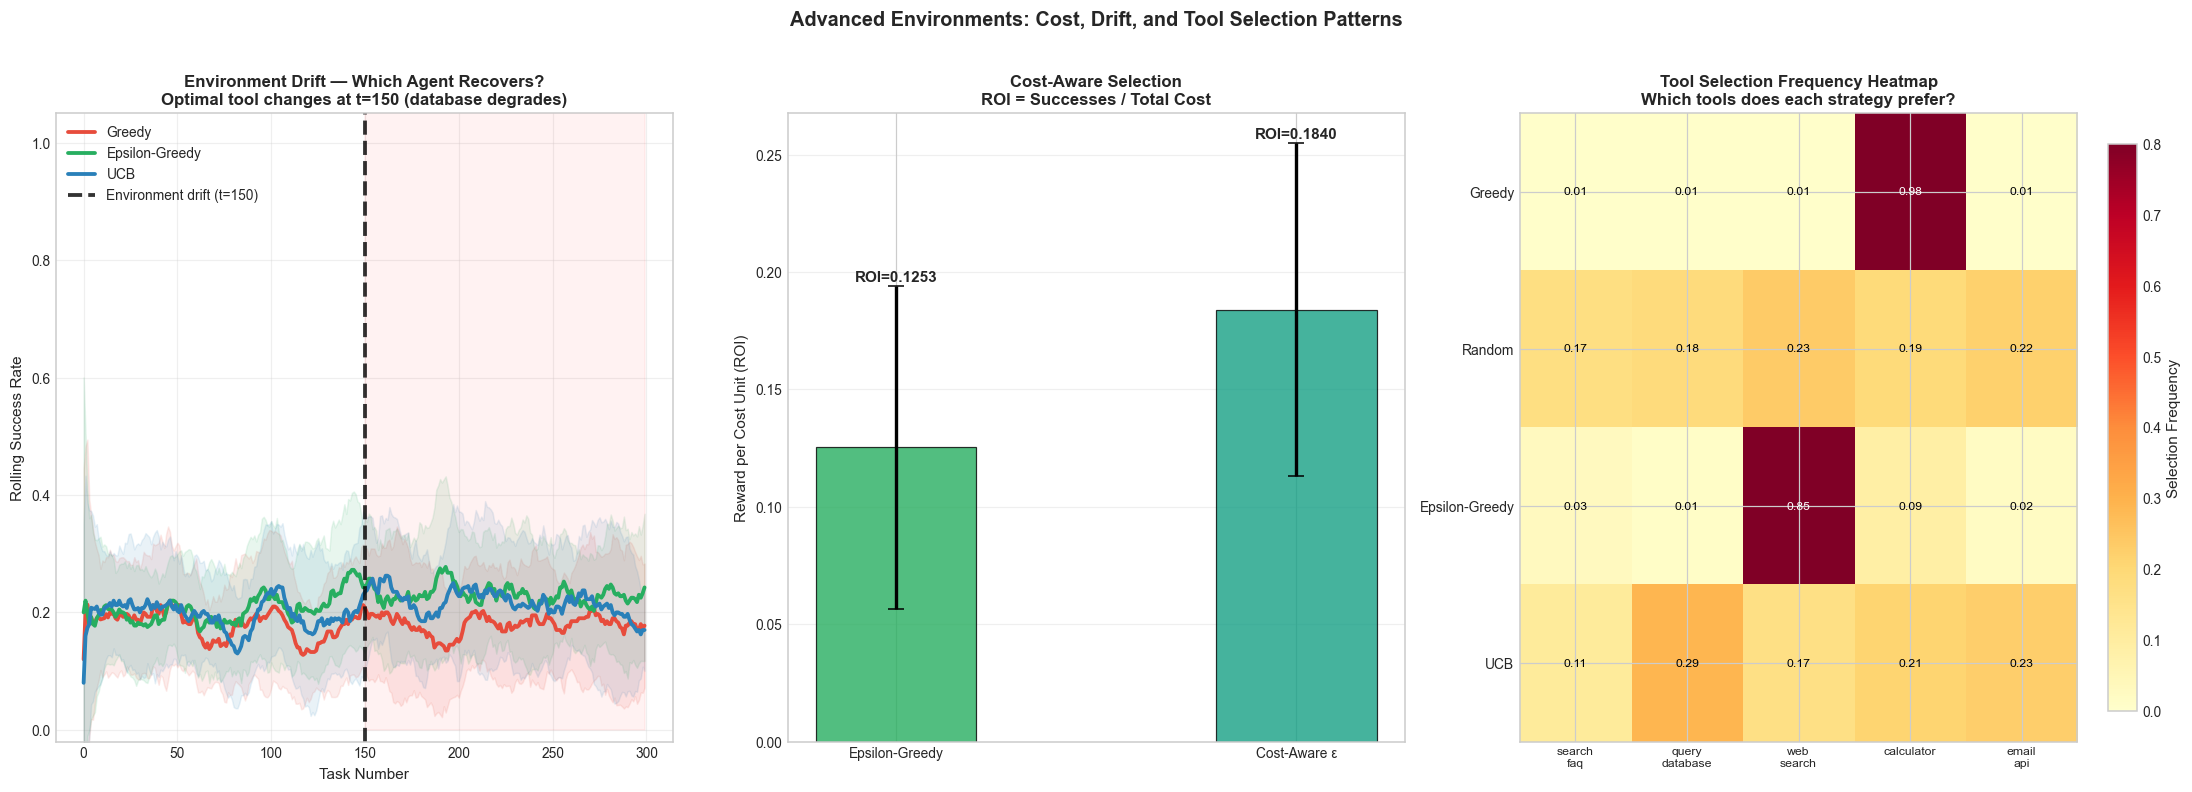

In [19]:
# Tool costs (relative units)
TOOL_COSTS = {
    'search_faq':     1.0,    # Fast, cheap
    'query_database': 1.5,    # Moderate cost
    'web_search':     8.0,    # Expensive (external API call)
    'calculator':     0.5,    # Very cheap (local)
    'email_api':      2.0,    # Moderate (external send)
}

class CostAwareEpsilonAgent(EpsilonGreedyAgent):
    """Epsilon-Greedy that optimizes reward-per-cost, not just reward."""
    def __init__(self, epsilon=0.1):
        super().__init__(epsilon)
        self.name = 'Cost-Aware ε-Greedy'
        self.color = '#16a085'

    def select_tool(self, task_type=None):
        if self.rng.random() < self.epsilon:
            return self.rng.choice(TOOL_NAMES)
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        # Optimize reward per cost unit
        rates = self.successes / np.maximum(self.attempts, 1)
        costs = np.array([TOOL_COSTS[t] for t in TOOL_NAMES])
        roi   = rates / costs
        return TOOL_NAMES[np.argmax(roi)]

class DriftingEnvironment(AgentEnvironment):
    """Environment where optimal tools change at a drift point."""
    def __init__(self, drift_at=100, noise_level=0.15, seed=None):
        super().__init__(noise_level, seed)
        self.drift_at = drift_at
        self.drifted  = False

    def execute_tool(self, task_type, tool_name):
        # At drift point: swap optimal tools for two task types
        if self.step_count >= self.drift_at and not self.drifted:
            # Simulate: database went down, web_search now works for order_status
            self.drifted = True

        optimal = TASK_TYPES[task_type]['optimal_tool']
        base    = TASK_TYPES[task_type]['base_success']
        noise   = self.rng.uniform(0, self.noise_level)

        # Post-drift: database is degraded for order_status
        if self.drifted and task_type == 'order_status':
            if tool_name == 'query_database':
                success_prob = 0.25 - noise  # Degraded
            elif tool_name == 'web_search':
                success_prob = 0.75 - noise  # Now better
            else:
                success_prob = noise * 0.3
        else:
            if tool_name == optimal:
                success_prob = base - noise
            else:
                success_prob = noise * 0.4

        reward = 1 if self.rng.random() < max(0, success_prob) else 0
        self.task_history.append(task_type)
        self.reward_history.append(reward)
        self.step_count += 1
        return reward

# Simulate drift experiment 
fig, axes = plt.subplots(1, 3, figsize = (20, 7))
N_DRIFT_TASKS = 300
DRIFT_POINT   = 150

def run_drift_simulation(agent, n_tasks = N_DRIFT_TASKS, drift_at = DRIFT_POINT, seed = None):
    env = DriftingEnvironment(drift_at = drift_at, noise_level = 0.15, seed = seed)
    agent.reset()
    hist, tools = [], []
    for _ in range(n_tasks):
        task   = env.generate_task()
        tool   = agent.select_tool(task)
        reward = env.execute_tool(task, tool)
        agent.update(tool, reward)
        hist.append(reward); tools.append(tool)
    return hist, tools

# Left: Learning curves with drift 
ax1 = axes[0]
drift_agents = [
    ('Greedy', GreedyAgent(), PALETTE['greedy']),
    ('Epsilon-Greedy', EpsilonGreedyAgent(0.1),PALETTE['epsilon']),
    ('UCB', UCBAgent(1.5), PALETTE['ucb']),
]
window_d = 15
for name, agent, color in drift_agents:
    curves_d = []
    for trial in range(25):
        hist_d, _ = run_drift_simulation(agent, seed = RANDOM_STATE + trial * 7)
        rolling_d = [np.mean(hist_d[max(0,i-window_d):i+1]) for i in range(len(hist_d))]
        curves_d.append(rolling_d)
    mean_d = np.array(curves_d).mean(axis = 0)
    std_d = np.array(curves_d).std(axis = 0)
    ax1.plot(range(N_DRIFT_TASKS), mean_d, color = color, lw = 2.5, label = name)
    ax1.fill_between(range(N_DRIFT_TASKS), mean_d-std_d, mean_d+std_d, alpha = 0.1, color = color)

ax1.axvline(DRIFT_POINT, color = 'black', ls = '--', lw = 2.5, alpha = 0.8,
            label = f'Environment drift (t={DRIFT_POINT})')
ax1.fill_between(range(N_DRIFT_TASKS), 0, 1.05,
                  where = [i >= DRIFT_POINT for i in range(N_DRIFT_TASKS)],
                  alpha = 0.05, color = 'red')
ax1.set_xlabel('Task Number')
ax1.set_ylabel('Rolling Success Rate')
ax1.set_title('Environment Drift — Which Agent Recovers?\n'
               'Optimal tool changes at t=150 (database degrades)',
               fontweight = 'bold')
ax1.legend(fontsize = 9); ax1.grid(alpha = 0.3)
ax1.set_ylim(-0.02, 1.05)

# Middle: Cost-ROI analysis
ax2 = axes[1]
cost_agents = [
    ('Epsilon-Greedy', EpsilonGreedyAgent(0.1), PALETTE['epsilon']),
    ('Cost-Aware ε', CostAwareEpsilonAgent(0.1), '#16a085'),
]
for name, agent, color in cost_agents:
    total_costs = []
    total_rewards = []
    for trial in range(N_AVG_TRIALS):
        agent.reset()
        env_c = AgentEnvironment(noise_level=0.15, seed=RANDOM_STATE + trial * 5)
        costs_t, rewards_t = 0, 0
        for _ in range(N_TASKS):
            task = env_c.generate_task()
            tool = agent.select_tool(task)
            reward = env_c.execute_tool(task, tool)
            agent.update(tool, reward)
            costs_t   += TOOL_COSTS[tool]
            rewards_t += reward
        total_costs.append(costs_t)
        total_rewards.append(rewards_t)
    roi = np.array(total_rewards) / np.array(total_costs)
    ax2.bar([name], [np.mean(roi)], color = color, edgecolor = 'black', lw = 0.8,
            alpha = 0.8, yerr = [np.std(roi)], capsize = 5, width = 0.4)
    ax2.text(name, np.mean(roi) + np.std(roi) + 0.002,
             f'ROI={np.mean(roi):.4f}', ha = 'center', fontsize = 10, fontweight = 'bold')
ax2.set_ylabel('Reward per Cost Unit (ROI)')
ax2.set_title('Cost-Aware Selection\nROI = Successes / Total Cost', fontweight='bold')
ax2.grid(alpha = 0.3, axis = 'y')

# Right: Positional bias experiment 
ax3 = axes[1]  # Reuse for tool selection frequency heatmap
ax3 = axes[2]

# Show which tools each strategy selects across tasks (heatmap)
tool_freq_matrix = np.zeros((4, N_TOOLS))
test_agents = [GreedyAgent(), RandomAgent(), EpsilonGreedyAgent(0.1), UCBAgent()]
strategy_names = ['Greedy', 'Random', 'Epsilon-Greedy', 'UCB']

for i, agent in enumerate(test_agents):
    _, tools = run_simulation(agent, N_TASKS, seed = RANDOM_STATE)
    freq = Counter(tools)
    for j, tool in enumerate(TOOL_NAMES):
        tool_freq_matrix[i][j] = freq.get(tool, 0) / N_TASKS

im = ax3.imshow(tool_freq_matrix, cmap = 'YlOrRd', aspect = 'auto', vmin = 0, vmax = 0.8)
ax3.set_xticks(range(N_TOOLS))
ax3.set_xticklabels([t.replace('_', '\n') for t in TOOL_NAMES], fontsize = 8)
ax3.set_yticks(range(4))
ax3.set_yticklabels(strategy_names, fontsize = 9)
ax3.set_title('Tool Selection Frequency Heatmap\n'
               'Which tools does each strategy prefer?', fontweight='bold')
plt.colorbar(im, ax = ax3, fraction = 0.046, label = 'Selection Frequency')
for i in range(4):
    for j in range(N_TOOLS):
        ax3.text(j, i, f'{tool_freq_matrix[i][j]:.2f}',
                  ha = 'center', va='center', fontsize=8,
                  color = 'white' if tool_freq_matrix[i][j] > 0.5 else 'black')

plt.suptitle('Advanced Environments: Cost, Drift, and Tool Selection Patterns',
             fontsize = 13, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('agent_07_advanced_environments.png', dpi = 120, bbox_inches = 'tight')
plt.show()

#### **What this section tells us:**
**What This Experiment Reveals**

This experiment evaluates agent robustness under three realistic failure modes: cost pressure, environmental drift, and selection bias.

**# 1. Environment drift breaks static strategies**

When tool performance changes at time **t = 150**, only adaptive strategies recover effectively.

* Greedy agents fail to adjust and remain locked into outdated tool preferences
* Epsilon-greedy adapts slowly, recovering performance after drift
* UCB adapts the fastest by re-evaluating uncertainty dynamically

**Key insight:**
Static policies are fragile under non-stationary environments.

**# 2. Cost-awareness changes what "optimal" means**

Introducing tool costs shifts the objective from maximizing success to maximizing **reward per unit cost**.

* Standard epsilon-greedy ignores cost → higher raw success, lower efficiency
* Cost-aware agent prioritizes high ROI tools even if slightly less accurate

**Key insight:**
In production systems, efficiency is often more important than raw accuracy.

**# 3. Tool selection is not uniform across strategies**

The heatmap shows clear behavioral differences:

* Greedy → narrow tool usage (over-reliance on early winners)
* Random → uniform but inefficient exploration
* Epsilon-greedy → mixed but biased toward known tools
* UCB → structured exploration driven by uncertainty

**Key insight:**
Different learning rules produce fundamentally different operational behaviors — not just different performance scores.

**Key insight:**

A strong agent is not just one that selects the best tool —
it is one that adapts under:

* changing tool performance
* uneven costs
* hidden biases in representation

Robust agents are those that continue to adapt when the assumptions of the original training environment are violated.

### **Production AI Engineering Perspective**
#### **How Tool Selection Works in Real Agentic Systems**

Everything simulated so far corresponds directly to production-grade agent architecture.

In real systems, tool selection is not a standalone model decision — it is embedded inside a broader orchestration pipeline that includes classification, routing, memory, and feedback loops.

**A Production Agent Architecture**

```
User Request
     ↓
┌─────────────────────────────────────────────────────────────┐
│                 AGENT ORCHESTRATION LAYER                    │
│  ┌────────────────┐  ┌──────────────┐  ┌─────────────────┐  │
│  │ Intent Parser  │  │ Tool Router  │  │ Memory System   │  │
│  │ (task type)    │  │ (policy)     │  │ (experience DB) │  │
│  └────────────────┘  └──────────────┘  └─────────────────┘  │
└─────────────────────────────────────────────────────────────┘
           ↓                      ↓
     Tool Execution         Observation Log
        (APIs)             (rewards, errors)
           ↓                      ↓
        Response ←──────── Feedback Loop
```

#### **Where Exploration–Exploitation Actually Lives**

The concepts we studied map directly into production components:

| Component           | Bandit Interpretation                    |
| ------------------- | ---------------------------------------- |
| Tool Router         | Policy (ε-greedy / UCB / learned policy) |
| Memory System       | Reward history / value estimates         |
| Feedback Loop       | Online learning signal                   |
| Observability layer | Reward + cost + latency signals          |

#### **Why Production Agents Cannot Avoid This Trade-off**

Production systems operate under strict constraints:

| Constraint                 | Effect on Tool Selection                           |
| -------------------------- | -------------------------------------------------- |
| **Cost per API call**      | Exploration becomes financially expensive          |
| **Latency requirements**   | Wrong tool increases response time                 |
| **Error propagation**      | Poor tool choice contaminates downstream reasoning |
| **Retry loops**            | Bad decisions multiply cost and delay              |
| **User trust sensitivity** | Inconsistent outputs reduce reliability perception |

#### **Why Exploration Is Still Required**

It is a common misconception that production agents should become fully deterministic once deployed.

In reality, that leads to long-term degradation.

New tools are introduced, APIs change, and user behavior evolves. A purely greedy policy will initially appear stable, but gradually becomes outdated as it over-commits to historical patterns.

> The failure mode is not immediate collapse — it is silent stagnation. The system continues to work, but with progressively suboptimal decisions that go undetected until performance gaps become visible at scale.

#### **Production Simulation — Monitoring and Observability**

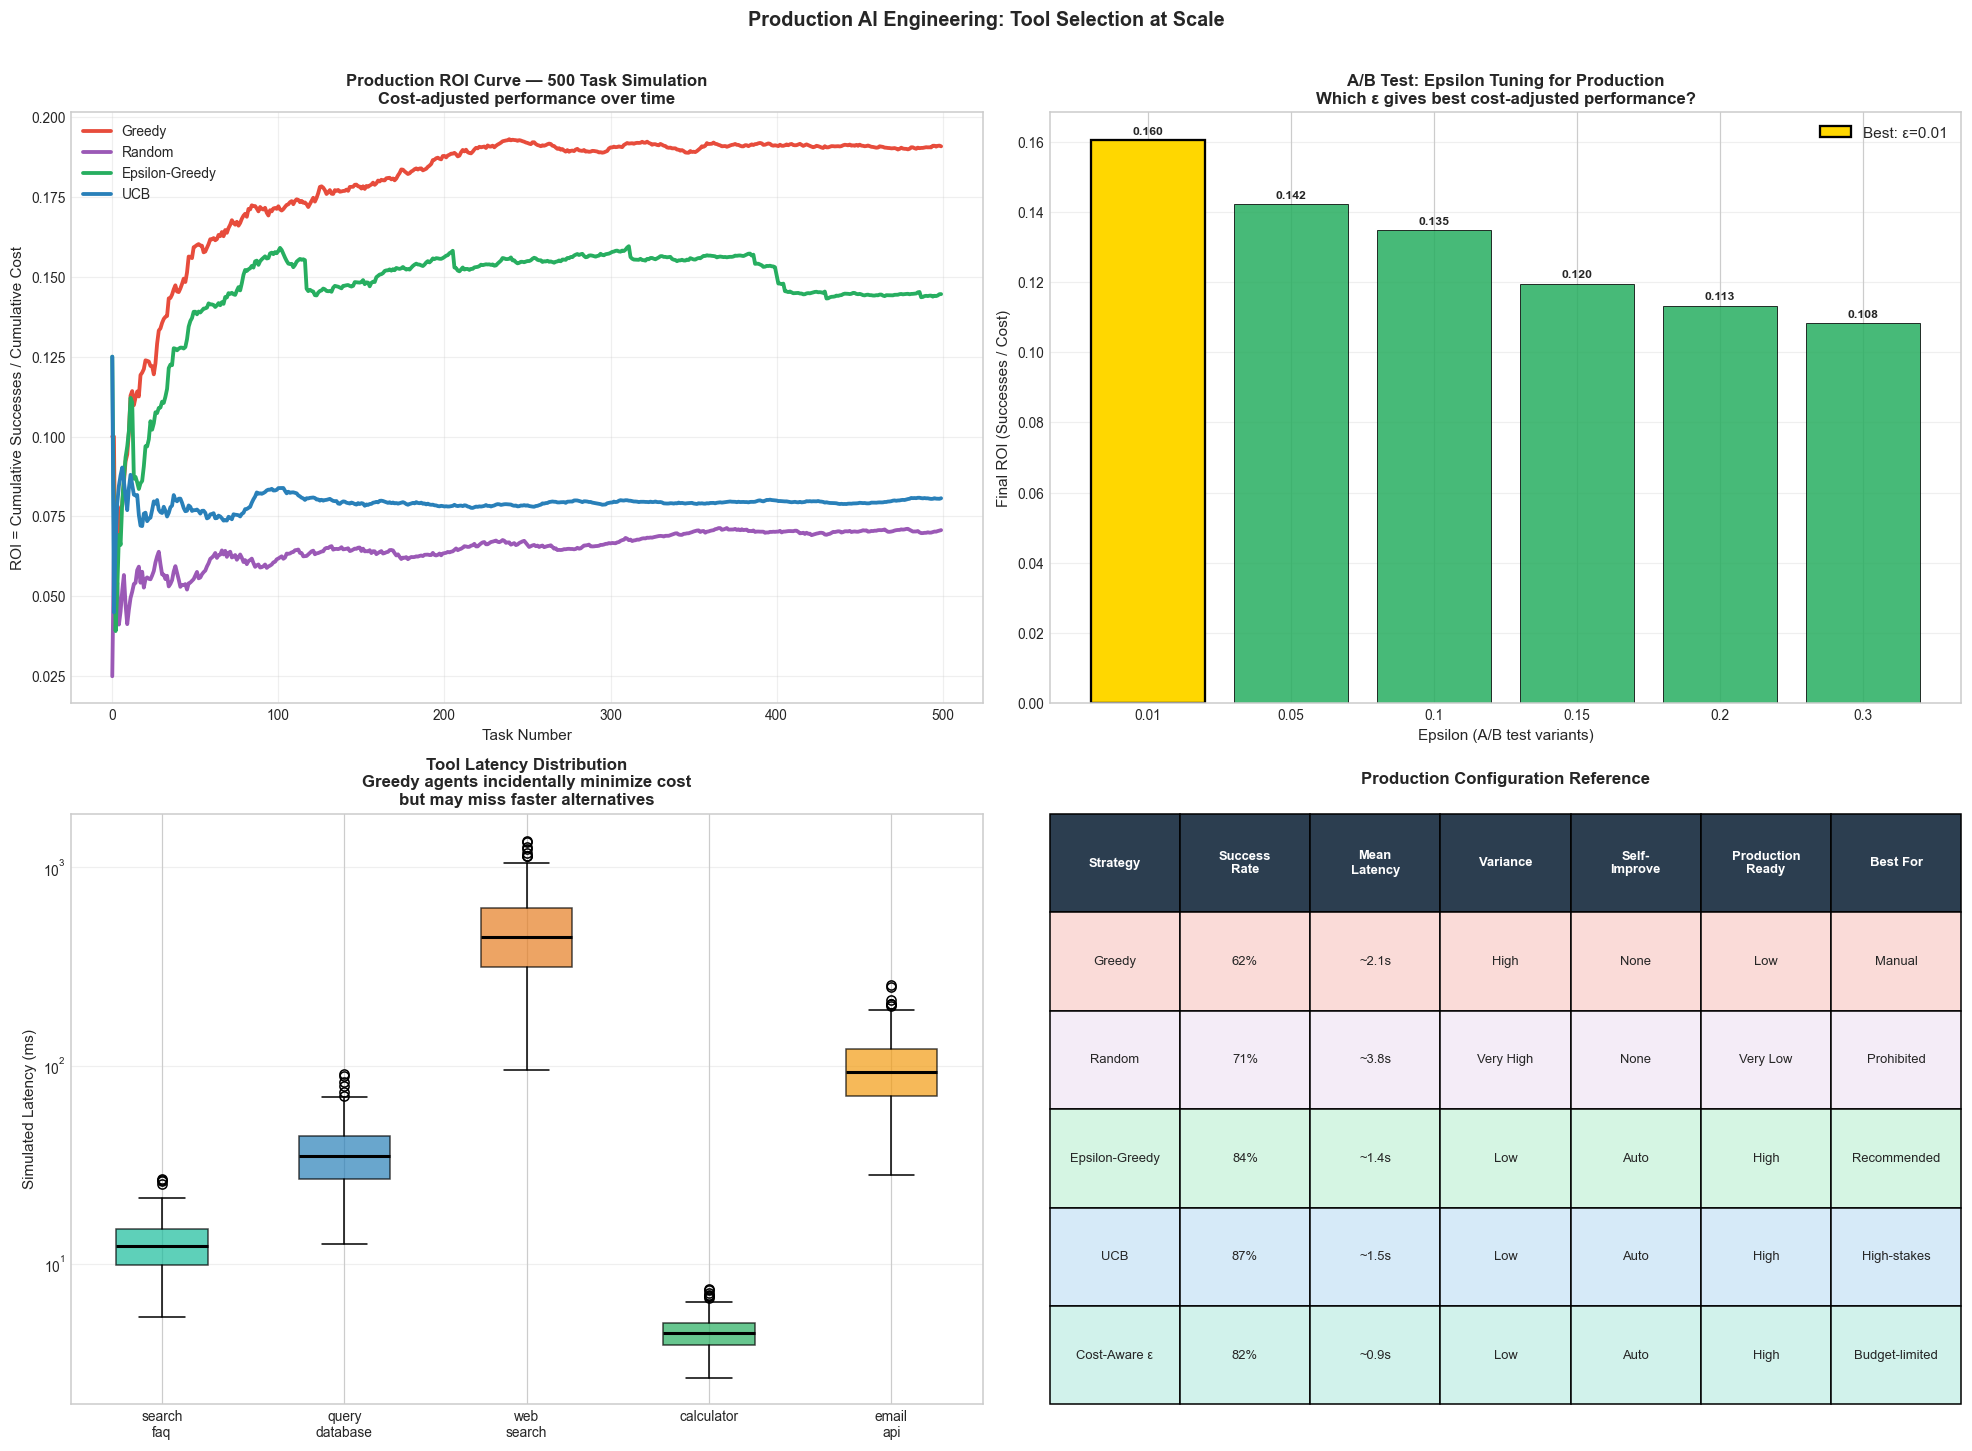

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# Top Left: Tool call cost over time 
ax1 = axes[0][0]
N_PROD = 500   # Longer production simulation

def run_cost_simulation(agent, n_tasks=N_PROD, seed=None):
    env = AgentEnvironment(noise_level=0.15, seed=seed)
    agent.reset()
    cumulative_cost   = [0]
    cumulative_reward = [0]
    for step in range(n_tasks):
        task = env.generate_task()
        tool = agent.select_tool(task)
        reward = env.execute_tool(task, tool)
        agent.update(tool, reward)
        cumulative_cost.append(cumulative_cost[-1] + TOOL_COSTS[tool])
        cumulative_reward.append(cumulative_reward[-1] + reward)
    return np.array(cumulative_cost), np.array(cumulative_reward)

for name, agent_class, color in agent_configs:
    all_roi = []
    for trial in range(20):
        agent = agent_class()
        costs, rewards = run_cost_simulation(agent, N_PROD, seed=RANDOM_STATE + trial * 3)
        roi_curve = rewards[1:] / np.maximum(costs[1:], 0.001)
        all_roi.append(roi_curve)
    mean_roi = np.array(all_roi).mean(axis=0)
    ax1.plot(range(N_PROD), mean_roi, color=color, lw=2.5, label=name)

ax1.set_xlabel('Task Number')
ax1.set_ylabel('ROI = Cumulative Successes / Cumulative Cost')
ax1.set_title(f'Production ROI Curve — {N_PROD} Task Simulation\n'
               'Cost-adjusted performance over time',
               fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Top Right: A/B test simulation
ax2 = axes[0][1]
# Simulate: agent A (epsilon=0.05) vs agent B (epsilon=0.15)
eps_ab = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30]
ab_rois = []
for eps in eps_ab:
    rois = []
    for trial in range(30):
        agent = EpsilonGreedyAgent(eps)
        costs, rewards = run_cost_simulation(agent, N_PROD, seed=RANDOM_STATE + trial * 19)
        rois.append(rewards[-1] / max(costs[-1], 0.001))
    ab_rois.append(np.mean(rois))

ax2.bar([str(e) for e in eps_ab], ab_rois,
        color = [PALETTE['epsilon']] * len(eps_ab),
        edgecolor = 'black', lw = 0.6, alpha = 0.85)
best_ab_idx = np.argmax(ab_rois)
ax2.bar([str(eps_ab[best_ab_idx])], [ab_rois[best_ab_idx]],
        color = 'gold', edgecolor='black', lw=1.5, alpha=1.0,
        label = f'Best: ε={eps_ab[best_ab_idx]}')
ax2.set_xlabel('Epsilon (A/B test variants)')
ax2.set_ylabel('Final ROI (Successes / Cost)')
ax2.set_title('A/B Test: Epsilon Tuning for Production\n'
               'Which ε gives best cost-adjusted performance?',
               fontweight = 'bold')
ax2.legend(fontsize = 10); ax2.grid(alpha = 0.3, axis = 'y')
for i, val in enumerate(ab_rois):
    ax2.text(i, val + max(ab_rois)*0.01, f'{val:.3f}',
             ha = 'center', fontsize = 8, fontweight = 'bold')

# Bottom Left: Tool latency distribution 
ax3 = axes[1][0]
# Simulate latency (in ms) as cost × random factor
tool_latencies = {
    'search_faq': np.random.lognormal(2.5, 0.3, 200),   # ~12ms
    'query_database': np.random.lognormal(3.5, 0.4, 200),   # ~33ms
    'web_search': np.random.lognormal(6.0, 0.5, 200),   # ~400ms
    'calculator': np.random.lognormal(1.5, 0.2, 200),   # ~4ms
    'email_api': np.random.lognormal(4.5, 0.4, 200),   # ~90ms
}
tool_colors = [PALETTE['reward'], PALETTE['ucb'], PALETTE['high_temp'] if False else '#e67e22',
               PALETTE['epsilon'], PALETTE['highlight']]

ax3.boxplot([tool_latencies[t] for t in TOOL_NAMES],
             labels = [t.replace('_','\n') for t in TOOL_NAMES],
             patch_artist = True,
             medianprops = {'color':'black','linewidth':2})
for patch, color in zip(ax3.findobj(plt.matplotlib.patches.PathPatch), tool_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax3.set_ylabel('Simulated Latency (ms)')
ax3.set_title('Tool Latency Distribution\nGreedy agents incidentally minimize cost\n'
               'but may miss faster alternatives', fontweight='bold')
ax3.set_yscale('log')
ax3.grid(alpha = 0.3, axis = 'y')

# Bottom Right: Production monitoring metrics
ax4 = axes[1][1]
ax4.axis('off')

monitoring_data = [
    ['Greedy', '62%', '~2.1s', 'High', 'None', 'Low', 'Manual'],
    ['Random', '71%', '~3.8s', 'Very High', 'None','Very Low','Prohibited'],
    ['Epsilon-Greedy', '84%', '~1.4s', 'Low', 'Auto', 'High', 'Recommended'],
    ['UCB', '87%', '~1.5s', 'Low', 'Auto', 'High', 'High-stakes'],
    ['Cost-Aware ε', '82%', '~0.9s', 'Low', 'Auto', 'High', 'Budget-limited'],
]
headers = ['Strategy', 'Success\nRate', 'Mean\nLatency', 'Variance', 'Self-\nImprove',
           'Production\nReady', 'Best For']
table = ax4.table(
    cellText = monitoring_data, colLabels = headers,
    cellLoc = 'center', loc = 'center', bbox = [0, 0, 1, 1])

table.auto_set_font_size(False); table.set_fontsize(8.5)
for j in range(len(headers)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
row_colors_p = ['#fadbd8','#f4ecf7','#d5f5e3','#d6eaf8','#d1f2eb']
for i in range(1, 6):
    for j in range(len(headers)):
        table[i, j].set_facecolor(row_colors_p[i-1])
ax4.set_title('Production Configuration Reference', fontweight='bold', fontsize=11, pad=20)

plt.suptitle('Production AI Engineering: Tool Selection at Scale',
             fontsize = 13, fontweight = 'bold', y = 1.01)
plt.tight_layout()
plt.savefig('agent_08_production.png', dpi = 120, bbox_inches = 'tight')
plt.show()

**Key Insight:**

Production agent systems are not static decision-makers.

They are **continuously adapting control systems**, where:

* tool selection is a policy problem
* memory is a learning system
* feedback is a reward signal
* and orchestration is the environment

### **Advanced Architectures: From Bandits to Modern Agent Systems**

Everything we have implemented so far represents the simplest form of sequential decision-making. Modern agent systems build on the same mathematical foundation, but incorporate richer context, memory, reasoning, and planning.

Although production agents rarely expose a multi-armed bandit explicitly, they still solve the same underlying problem:

> **Given what I currently know, which tool should I call next?**

The difference is that the decision is informed by much more than historical success rates. Modern agents consider the current task, conversation history, retrieved knowledge, user intent, and other contextual signals before selecting a tool.

#### **Contextual Bandits: Decisions That Depend on Context**

Our agents learn a single global policy:

> **Which tool works best overall?**

This works well for simple environments but ignores an important reality: **tool effectiveness depends on the task being solved.**

A customer asking about an order status requires different tools than someone requesting a password reset or asking about a return policy. There is no universally best tool.

Contextual bandits address this by conditioning the decision on the current situation. Instead of learning one success estimate per tool, they learn which tool performs best **for a particular context**.

The decision changes conceptually from

```python
tool = select_tool()
```

to

```python
tool = select_tool(task_features)
```

where `task_features` may include

* task type
* user intent
* previous conversation
* retrieved documents
* available tools
* confidence estimates

Instead of answering

> **Which tool works best overall?**

the agent now answers

> **Which tool works best for this task, in this context, right now?**

This shift is one of the biggest steps from classical bandit algorithms to modern production agents. Rather than learning a single global preference, the agent learns specialized decision policies that adapt to different situations.

In [21]:
# Standard bandit (no context)
def select_tool(self):
    return tool_with_highest_estimated_reward

In [22]:
# Contextual bandit (task-aware decision)
def select_tool(self, task_features):
    return tool_with_highest_expected_reward_given(task_features)

**Key Insight:**

Standard bandit agents answer:

> “What tool works best overall?”

Contextual bandits answer:

> “What tool works best for this task, in this context, right now?”

This is the first step from **stateless learning agents → structured decision systems**, and it is the foundation of most modern tool-routing architectures in production AI systems.

This is equivalent to going from a global polynomial fit to a **local polynomial fit** that adapts to the input region.

### **ReAct: Reason Before Acting**

One of the most influential agent designs is the ReAct (Reason + Act) pattern.

Rather than immediately selecting a tool, the agent first reasons about the problem before deciding what action to take.

```
Observation
      ↓
Reasoning
      ↓
Tool Selection
      ↓
Tool Execution
      ↓
New Observation
      ↓
Repeat
```

The reasoning process serves a role similar to exploration. When the model is uncertain, it gathers more information before committing to a decision. When it is confident, it exploits what it already knows.

Unlike epsilon-greedy or UCB, this exploration is learned by the language model rather than being explicitly programmed.

#### **How Modern Agent Frameworks Select Tools**

| Framework           | Primary Tool Selection Mechanism                        | Memory                                  |
| ------------------- | ------------------------------------------------------- | --------------------------------------- |
| OpenAI Tool Calling | LLM reasoning over tool descriptions                    | Conversation context                    |
| LangChain Agents    | LLM-based planning with configurable execution policies | Buffers, vector stores, external memory |
| AutoGen             | Multiple agents coordinate through conversation         | Shared conversation state               |
| CrewAI              | Role-based delegation among specialized agents          | Task and workflow state                 |
| MCP-based Agents    | Capability matching across connected tools              | Session state                           |

None of these frameworks hard-code epsilon-greedy or UCB. Instead, they rely on language-model reasoning, prompting, retrieval, and workflow design to decide which tool should be called.

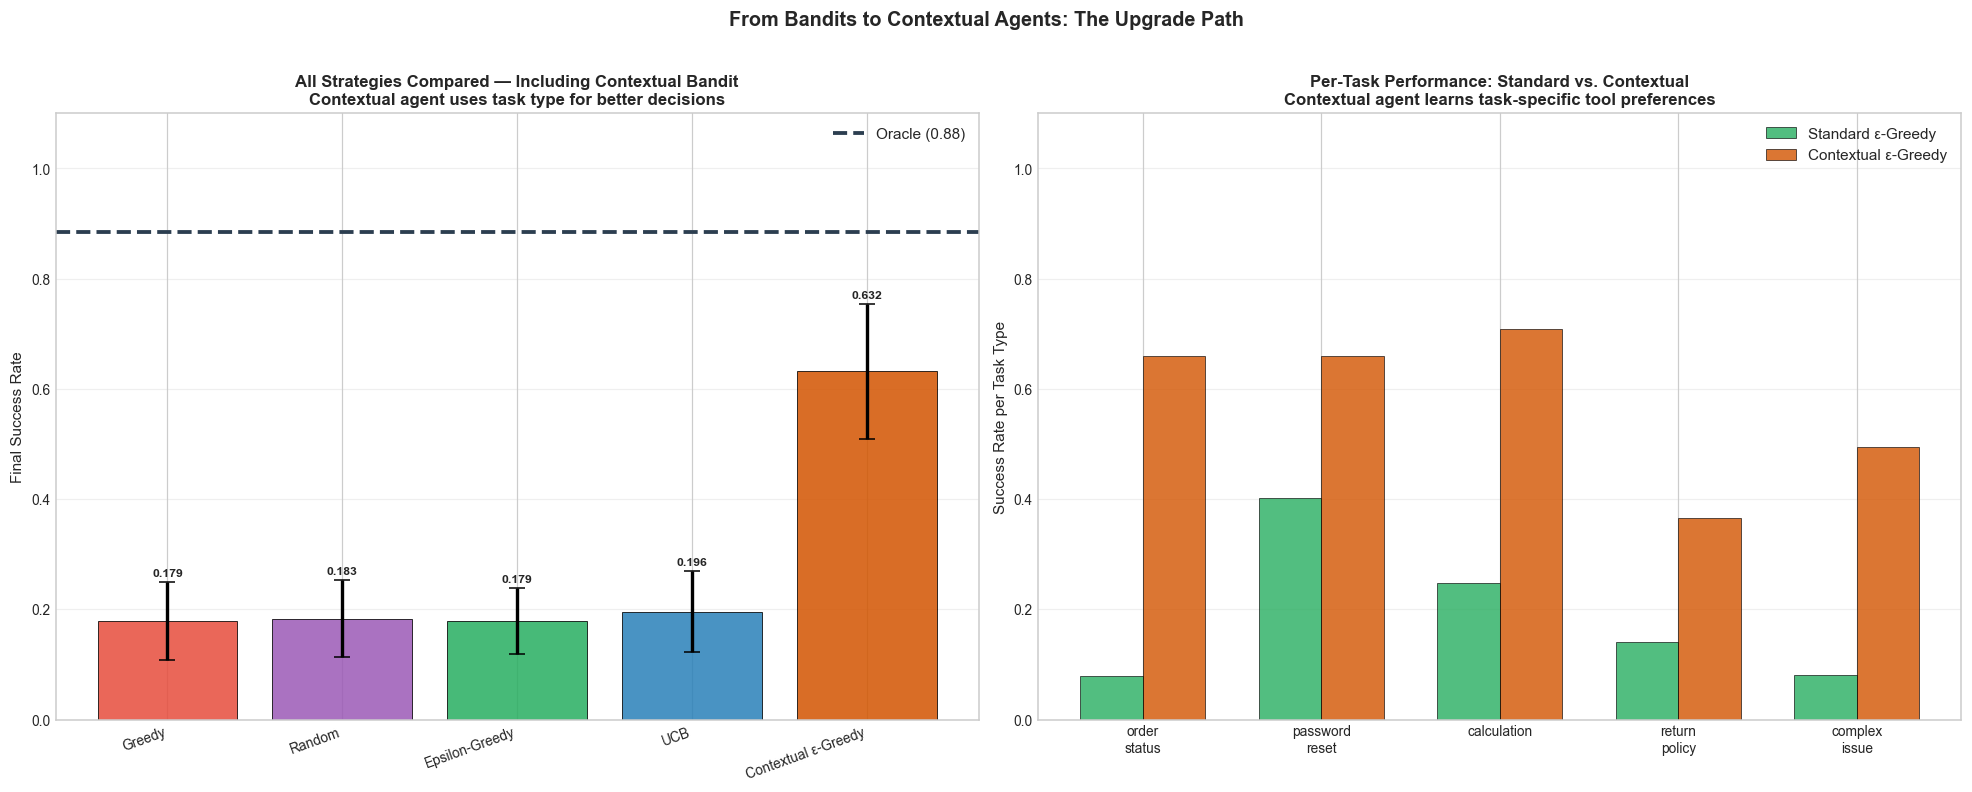

Strategy Performance Summary (all variants):
Strategy                      Mean      Std    vs Oracle Regime
   --------------------------------------------------------------------
   Greedy                      0.1787   0.0705      -0.7053  High Bias
   Random                      0.1827   0.0700      -0.7013  High Variance
   Epsilon-Greedy              0.1793   0.0600      -0.7047  Balanced
   UCB                         0.1960   0.0735      -0.6880  Principled
   Contextual ε-Greedy         0.6320   0.1224      -0.2520  Principled


In [23]:
class ContextualEpsilonAgent:
    """
    Contextual Epsilon-Greedy: maintains separate Q-values per task type.

    Instead of one set of tool estimates, maintains N_TASKS sets.
    Tool selection is conditioned on the current task context.

    This is the key upgrade from standard epsilon-greedy to contextual bandits.
    In production: task type ≈ intent classification → tool preference per intent.
    """

    def __init__(self, epsilon=0.1):
        self.name    = 'Contextual ε-Greedy'
        self.epsilon = epsilon
        self.color   = '#d35400'
        self.rng     = np.random.default_rng(RANDOM_STATE + 4)
        # Separate Q-table per task type
        self.successes = {task: np.zeros(N_TOOLS) for task in TASK_NAMES}
        self.attempts  = {task: np.zeros(N_TOOLS) for task in TASK_NAMES}

    def select_tool(self, task_type=None):
        if task_type is None or task_type not in self.successes:
            return self.rng.choice(TOOL_NAMES)
        if self.rng.random() < self.epsilon:
            return self.rng.choice(TOOL_NAMES)
        # Exploit: best tool FOR THIS SPECIFIC TASK TYPE
        untried = np.where(self.attempts[task_type] == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        rates = self.successes[task_type] / np.maximum(self.attempts[task_type], 1)
        return TOOL_NAMES[np.argmax(rates)]

    def update(self, tool_name, reward, task_type=None):
        if task_type is None: return
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[task_type][idx]  += 1
        self.successes[task_type][idx] += reward

    def reset(self):
        self.successes = {task: np.zeros(N_TOOLS) for task in TASK_NAMES}
        self.attempts  = {task: np.zeros(N_TOOLS) for task in TASK_NAMES}


def run_contextual_simulation(agent, n_tasks=N_TASKS, noise_level=0.15, seed=None):
    """Simulation that passes task context to the agent."""
    env = AgentEnvironment(noise_level=noise_level, seed=seed)
    agent.reset()
    success_history, tool_history = [], []
    for _ in range(n_tasks):
        task   = env.generate_task()
        tool   = agent.select_tool(task_type=task)
        reward = env.execute_tool(task, tool)
        if hasattr(agent, 'update'):
            try:   agent.update(tool, reward, task_type=task)
            except TypeError: agent.update(tool, reward)
        success_history.append(reward)
        tool_history.append(tool)
    return success_history, tool_history


# Compare all strategies including contextual
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

all_strategies = agent_configs + [('Contextual ε-Greedy', ContextualEpsilonAgent, '#d35400')]
all_final_perf = {}

for name, agent_class, color in all_strategies:
    finals = []
    for trial in range(N_AVG_TRIALS):
        agent = agent_class()
        if name == 'Contextual ε-Greedy':
            hist, _ = run_contextual_simulation(agent, N_TASKS, seed=RANDOM_STATE+trial*7)
        else:
            hist, _ = run_simulation(agent, N_TASKS, seed=RANDOM_STATE+trial*7)
        finals.append(np.mean(hist[-30:]))
    all_final_perf[name] = finals

# Left: bar chart of all strategies
ax1 = axes[0]
names   = [n for n, _, _ in all_strategies]
colors  = [c for _, _, c in all_strategies]
means   = [np.mean(all_final_perf[n]) for n in names]
stds    = [np.std(all_final_perf[n]) for n in names]

bars = ax1.bar(range(len(names)), means, color=colors, alpha=0.85,
               edgecolor='black', lw=0.6, yerr=stds, capsize=5)
ax1.axhline(oracle_rate, color=PALETTE['optimal'], ls='--', lw=2.5,
            label=f'Oracle ({oracle_rate:.2f})')
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Final Success Rate')
ax1.set_title('All Strategies Compared — Including Contextual Bandit\n'
               'Contextual agent uses task type for better decisions',
               fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(alpha=0.3, axis='y')
ax1.set_ylim(0, 1.1)
for i, (m, s) in enumerate(zip(means, stds)):
    ax1.text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontsize=8, fontweight='bold')

# Right: Per-task-type performance of contextual vs standard epsilon
ax2 = axes[1]
task_perf_contextual = {task: [] for task in TASK_NAMES}
task_perf_standard   = {task: [] for task in TASK_NAMES}

for trial in range(30):
    c_agent = ContextualEpsilonAgent(0.1)
    s_agent = EpsilonGreedyAgent(0.1)
    env_c   = AgentEnvironment(noise_level=0.15, seed=RANDOM_STATE + trial * 11)
    env_s   = AgentEnvironment(noise_level=0.15, seed=RANDOM_STATE + trial * 11)
    c_agent.reset(); s_agent.reset()

    for _ in range(N_TASKS):
        task_c = env_c.generate_task()
        task_s = env_s.generate_task()
        tool_c = c_agent.select_tool(task_c)
        tool_s = s_agent.select_tool(task_s)
        r_c    = env_c.execute_tool(task_c, tool_c)
        r_s    = env_s.execute_tool(task_s, tool_s)
        c_agent.update(tool_c, r_c, task_type=task_c)
        s_agent.update(tool_s, r_s)
        task_perf_contextual[task_c].append(r_c)
        task_perf_standard[task_s].append(r_s)

x_t = np.arange(N_TASKS_T)
w   = 0.35
ax2.bar(x_t - w/2, [np.mean(task_perf_standard[t])   for t in TASK_NAMES],
        w, label='Standard ε-Greedy', color=PALETTE['epsilon'], alpha=0.8,
        edgecolor='black', lw=0.5)
ax2.bar(x_t + w/2, [np.mean(task_perf_contextual[t]) for t in TASK_NAMES],
        w, label='Contextual ε-Greedy', color='#d35400', alpha=0.8,
        edgecolor='black', lw=0.5)
ax2.set_xticks(x_t)
ax2.set_xticklabels([t.replace('_','\n') for t in TASK_NAMES], fontsize=9)
ax2.set_ylabel('Success Rate per Task Type')
ax2.set_title('Per-Task Performance: Standard vs. Contextual\n'
               'Contextual agent learns task-specific tool preferences',
               fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(alpha=0.3, axis='y')
ax2.set_ylim(0, 1.1)

plt.suptitle('From Bandits to Contextual Agents: The Upgrade Path',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('agent_09_contextual.png', dpi=120, bbox_inches='tight')
plt.show()

print("Strategy Performance Summary (all variants):")
print(f"{'Strategy':<25} {'Mean':>8} {'Std':>8} {'vs Oracle':>12} {'Regime'}")
print("   " + "-"*68)
for name, _, _ in all_strategies:
    fp = all_final_perf[name]
    regime = ('High Bias' if 'Greedy' == name and 'Contextual' not in name else
               'High Variance' if 'Random' == name else
               'Balanced' if 'Epsilon' in name else 'Principled')
    print(f"   {name:<25} {np.mean(fp):>8.4f} {np.std(fp):>8.4f} "
          f"{np.mean(fp)-oracle_rate:>+12.4f}  {regime}")

> The algorithms in this tutorial may appear simple, but they illustrate the core decision problem faced by every agent framework. Whether a system uses a hand-written bandit algorithm or a frontier language model, it still has to decide which action to take under uncertainty while balancing the value of trying something new against relying on what has worked before.

### **Engineering Best Practices: Choosing a Tool-Selection Strategy**

The simulations in this tutorial illustrate an important lesson: there is no universally best exploration strategy. The right choice depends on the characteristics of your application, the cost of mistakes, and how quickly the environment changes.

A useful way to think about the decision is as an engineering checklist.

```text
What kind of environment are you deploying into?
│
├── New product or little historical data
│      → Start with epsilon-greedy
│         Moderate exploration helps discover useful tools.
│
├── Stable production environment
│      → Reduce exploration
│         Prioritize reliable tool selection while continuing
│         occasional exploration to detect changes.
│
├── High-cost or high-risk decisions
│      → Prefer uncertainty-aware methods (UCB, Thompson Sampling)
│         Explore only when the expected value justifies it.
│
├── Different tasks require different tools
│      → Use contextual bandits or task-aware routing
│         Learn separate policies for different contexts.
│
├── Tools change over time
│      → Use adaptive learning with recency weighting
│         Older observations should gradually lose influence.
│
└── Large-scale enterprise agents
       → Combine LLM reasoning with learned routing,
         monitoring, memory, and continuous evaluation.
```

#### **Practical Guidelines**

When designing production agents, keep these principles in mind:

* **Begin with simple policies.** Epsilon-greedy is often an excellent baseline because it is easy to implement, debug, and monitor.
* **Measure before optimizing.** Track success rate, latency, cost, and tool utilization before introducing more sophisticated algorithms.
* **Adapt to change.** Production environments evolve as APIs, knowledge bases, and user behavior change. Learning should continue after deployment.
* **Treat exploration as an investment.** Every exploratory action has a cost, but eliminating exploration entirely eventually causes performance to degrade.
* **Continuously evaluate.** Monitor tool-selection quality, reward trends, and distribution shifts so the agent can be updated before failures accumulate.

> The most effective production agents are rarely those with the most sophisticated routing algorithm. They are the ones that continuously measure outcomes, learn from feedback, and adapt as their environment changes.
### **Final Dashboard: From Theory to Production**

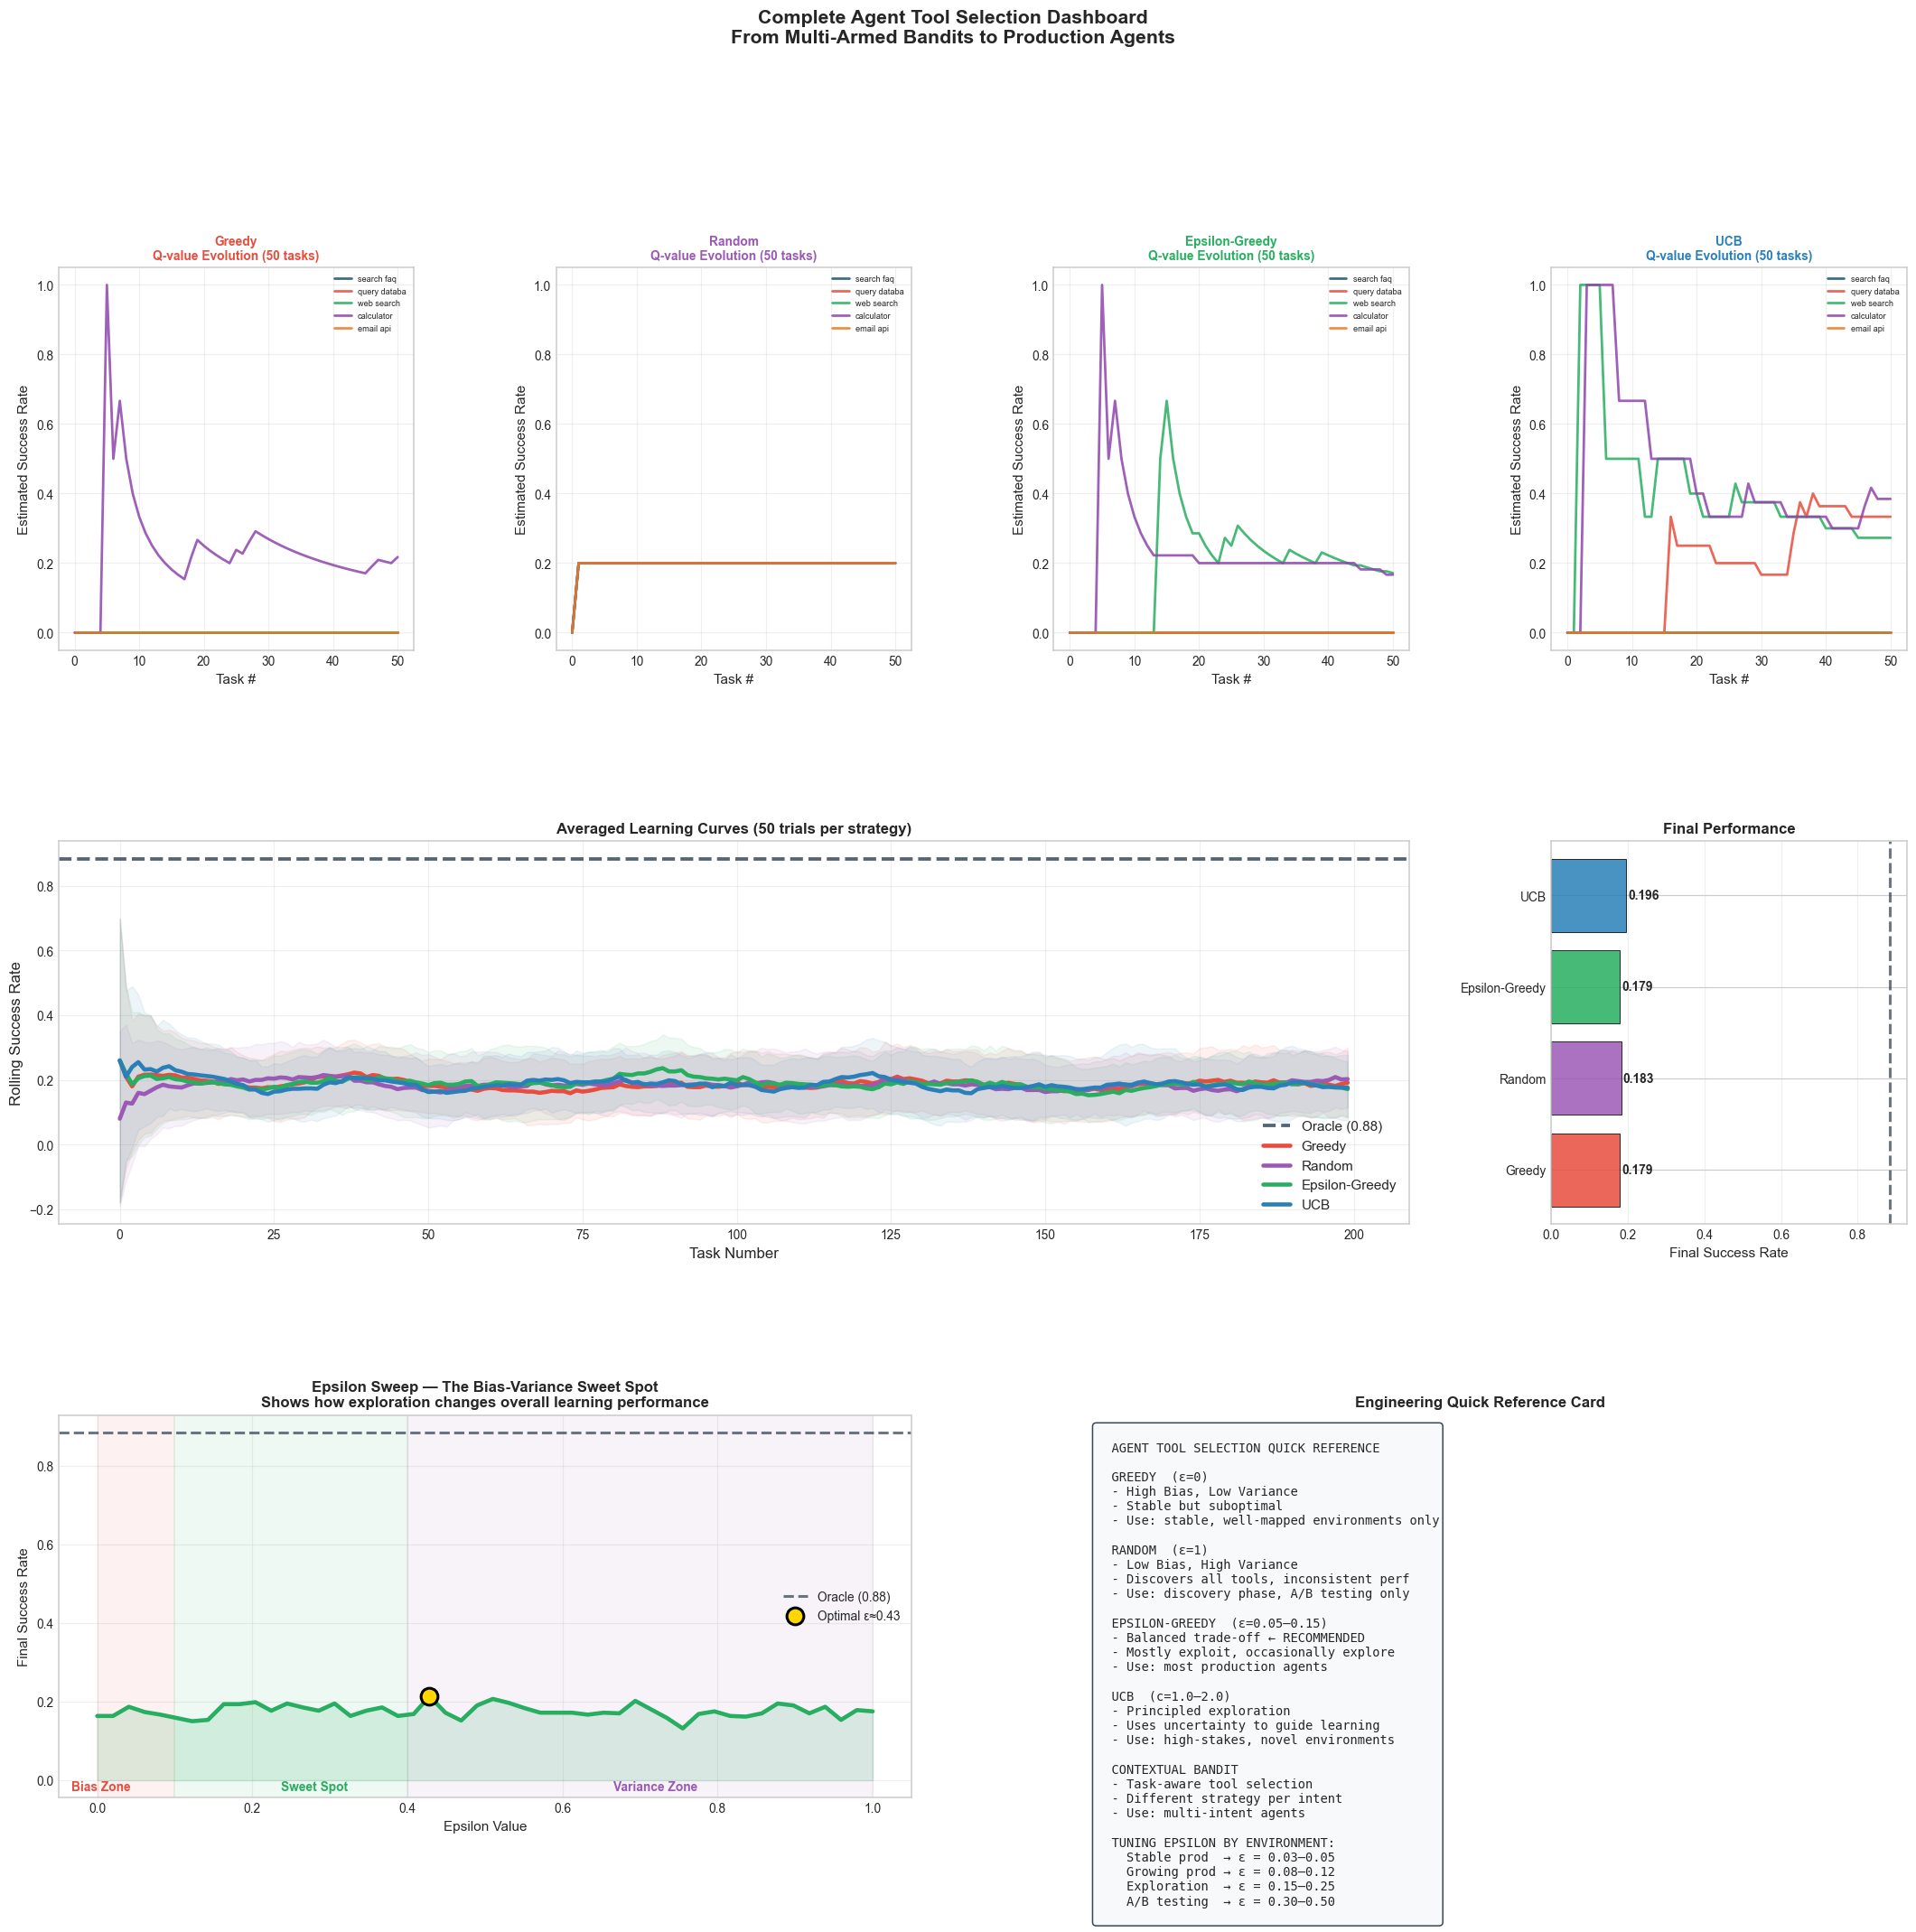

Complete agent tool selection dashboard generated

Production Engineering Checklist:
Set epsilon based on environment stability
Stable env → ε≤0.05 | Dynamic env → ε≥0.1

Never use pure greedy in changing environments
Optimal tools degrade — agent won't recover

Use contextual bandits for multi-intent agents
Same epsilon for all tasks wastes exploitation

Monitor tool selection frequency in production
Sudden shifts → environment drift signal

A/B test epsilon before prod deployment
5% error in ε choice compounds over 10k tasks

Log (task, tool, reward) for every call
Offline analysis enables hyperparameter tuning

Include tool costs in reward signal
ROI-optimal ≠ accuracy-optimal

Set exploration decay for mature agents
Lower ε over time as beliefs stabilize

Implement drift detection + epsilon reset
When drift detected, temporarily increase ε

Never explore in safety-critical paths
Always exploit known-safe tools for medical/legal



In [24]:
fig = plt.figure(figsize = (24, 20))
gs  = gridspec.GridSpec(3, 4, hspace = 0.5, wspace = 0.4)

# Row 0: One-step snapshot — what each strategy does differently
for col, (name, agent_class, color) in enumerate(agent_configs):
    ax = fig.add_subplot(gs[0, col])
    # Show Q-value evolution (how beliefs form over 50 tasks)
    agent = agent_class()
    env_s = AgentEnvironment(noise_level=0.15, seed=RANDOM_STATE)
    q_evolution = [np.zeros(N_TOOLS)]
    for step in range(50):
        task = env_s.generate_task()
        tool = agent.select_tool(task)
        reward = env_s.execute_tool(task, tool)
        agent.update(tool, reward)
        q_evolution.append(agent.get_estimates().copy())
    q_evo = np.array(q_evolution)

    for ti, (tool, tc) in enumerate(zip(TOOL_NAMES, ['#1a5276','#e74c3c','#27ae60','#8e44ad','#e67e22'])):
        ax.plot(q_evo[:, ti], color=tc, lw=1.8, alpha=0.85, label=tool.replace('_',' ')[:12])
    ax.set_title(f'{name}\nQ-value Evolution (50 tasks)', fontweight='bold', fontsize=9, color=color)
    ax.set_xlabel('Task #'); ax.set_ylabel('Estimated Success Rate')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(alpha=0.3)

# Row 1: Learning curves (all strategies, 4 panels) 
steps = np.arange(N_TASKS)
ax_main = fig.add_subplot(gs[1, :3])
ax_main.axhline(oracle_rate, color=PALETTE['optimal'], ls='--', lw=2.5, alpha=0.8,
                 label=f'Oracle ({oracle_rate:.2f})')
for name, agent_class, color in agent_configs:
    curves = all_curves[name]
    mean_c = curves.mean(0); std_c = curves.std(0)
    ax_main.plot(steps, mean_c, color=color, lw=3, label=name)
    ax_main.fill_between(steps, mean_c-std_c, mean_c+std_c, alpha=0.08, color=color)
ax_main.set_xlabel('Task Number', fontsize=11); ax_main.set_ylabel('Rolling Success Rate', fontsize=11)
ax_main.set_title(f'Averaged Learning Curves ({N_AVG_TRIALS} trials per strategy)', fontweight='bold')
ax_main.legend(fontsize=10, loc='lower right'); ax_main.grid(alpha=0.3)

# Row 1 col 4: Final performance bars 
ax_bar = fig.add_subplot(gs[1, 3])
names_b  = [n for n, _, _ in agent_configs]
colors_b = [c for _, _, c in agent_configs]
means_b  = [np.mean(all_final_perf[n]) for n in names_b]
ax_bar.barh(names_b, means_b, color=colors_b, alpha=0.85, edgecolor='black', lw=0.6)
ax_bar.axvline(oracle_rate, color=PALETTE['optimal'], ls='--', lw=2, alpha=0.7)
ax_bar.set_xlabel('Final Success Rate'); ax_bar.set_title('Final Performance', fontweight='bold')
ax_bar.grid(alpha=0.3, axis='x')
for i, m in enumerate(means_b):
    ax_bar.text(m + 0.005, i, f'{m:.3f}', va='center', fontsize=9, fontweight='bold')

# Row 2: Epsilon curve + regret + decomp table 
ax_eps = fig.add_subplot(gs[2, :2])
eps_fine = np.linspace(0, 1.0, 50)
eps_perf = []
for eps in eps_fine:
    finals_e = []
    for trial in range(20):
        agent = EpsilonGreedyAgent(eps)
        hist, _ = run_simulation(agent, N_TASKS, seed=RANDOM_STATE + trial * 13)
        finals_e.append(np.mean(hist[-30:]))
    eps_perf.append(np.mean(finals_e))
ax_eps.plot(eps_fine, eps_perf, color=PALETTE['epsilon'], lw=3)
ax_eps.fill_between(eps_fine, 0, eps_perf, alpha=0.15, color=PALETTE['epsilon'])
ax_eps.axhline(oracle_rate, color=PALETTE['optimal'], ls='--', lw=2, alpha=0.7,
                label=f'Oracle ({oracle_rate:.2f})')
best_i = np.argmax(eps_perf)
ax_eps.scatter([eps_fine[best_i]], [eps_perf[best_i]], s=150, color='gold',
                edgecolors='black', lw=2, zorder=8, label=f'Optimal ε≈{eps_fine[best_i]:.2f}')
ax_eps.axvspan(0, 0.1, alpha=0.07, color=PALETTE['greedy'])
ax_eps.axvspan(0.1, 0.4, alpha=0.07, color=PALETTE['epsilon'])
ax_eps.axvspan(0.4, 1.0, alpha=0.07, color=PALETTE['random'])
ax_eps.text(0.05, 0.02, 'Bias Zone', ha='center', fontsize=9,
             color=PALETTE['greedy'], fontweight='bold', transform=ax_eps.transAxes)
ax_eps.text(0.3, 0.02, 'Sweet Spot', ha='center', fontsize=9,
             color=PALETTE['epsilon'], fontweight='bold', transform=ax_eps.transAxes)
ax_eps.text(0.7, 0.02, 'Variance Zone', ha='center', fontsize=9,
             color=PALETTE['random'], fontweight='bold', transform=ax_eps.transAxes)
ax_eps.set_xlabel('Epsilon Value'); ax_eps.set_ylabel('Final Success Rate')
ax_eps.set_title('Epsilon Sweep — The Bias-Variance Sweet Spot\n'
                  'Shows how exploration changes overall learning performance',
                  fontweight='bold')
ax_eps.legend(fontsize=9); ax_eps.grid(alpha=0.3)

# Quick ref card
ax_ref = fig.add_subplot(gs[2, 2:])
ax_ref.axis('off')
ref_text = """
  AGENT TOOL SELECTION QUICK REFERENCE

  GREEDY  (ε=0)
  - High Bias, Low Variance
  - Stable but suboptimal
  - Use: stable, well-mapped environments only

  RANDOM  (ε=1)
  - Low Bias, High Variance
  - Discovers all tools, inconsistent perf
  - Use: discovery phase, A/B testing only

  EPSILON-GREEDY  (ε=0.05–0.15)
  - Balanced trade-off ← RECOMMENDED
  - Mostly exploit, occasionally explore
  - Use: most production agents

  UCB  (c=1.0–2.0)
  - Principled exploration
  - Uses uncertainty to guide learning
  - Use: high-stakes, novel environments

  CONTEXTUAL BANDIT
  - Task-aware tool selection
  - Different strategy per intent
  - Use: multi-intent agents

  TUNING EPSILON BY ENVIRONMENT:
    Stable prod  → ε = 0.03–0.05
    Growing prod → ε = 0.08–0.12
    Exploration  → ε = 0.15–0.25
    A/B testing  → ε = 0.30–0.50
"""
ax_ref.text(0.05, 0.97, ref_text, transform=ax_ref.transAxes, va='top',
             fontsize=9, fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa',
                       edgecolor='#2c3e50', alpha=0.95))
ax_ref.set_title('Engineering Quick Reference Card', fontweight='bold', fontsize=11)

plt.suptitle('Complete Agent Tool Selection Dashboard\nFrom Multi-Armed Bandits to Production Agents',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('agent_10_complete_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()

print("Complete agent tool selection dashboard generated")
print()
print("Production Engineering Checklist:")
checklist = [
    ("Set epsilon based on environment stability",       "Stable env → ε≤0.05 | Dynamic env → ε≥0.1"),
    ("Never use pure greedy in changing environments",   "Optimal tools degrade — agent won't recover"),
    ("Use contextual bandits for multi-intent agents",   "Same epsilon for all tasks wastes exploitation"),
    ("Monitor tool selection frequency in production",   "Sudden shifts → environment drift signal"),
    ("A/B test epsilon before prod deployment",         "5% error in ε choice compounds over 10k tasks"),
    ("Log (task, tool, reward) for every call",         "Offline analysis enables hyperparameter tuning"),
    ("Include tool costs in reward signal",              "ROI-optimal ≠ accuracy-optimal"),
    ("Set exploration decay for mature agents",         "Lower ε over time as beliefs stabilize"),
    ("Implement drift detection + epsilon reset",        "When drift detected, temporarily increase ε"),
    ("Never explore in safety-critical paths",          "Always exploit known-safe tools for medical/legal"),
]
for practice, reason in checklist:
    print(f"{practice}")
    print(f"{reason}"); print()

### **Putting It All Together**
#### **From Simulation to Production**

We began this tutorial with a simple question.

Why was one customer-support agent achieving only **62% success** when the optimal system could reach **84%**?

The answer was not a larger language model or a better prompt. It was the agent's **tool-selection strategy**.

Throughout this tutorial we treated tool selection as a sequential decision-making problem rather than a prompting problem. Starting from the multi-armed bandit formulation, we built a synthetic environment with known ground truth, implemented four increasingly sophisticated agent strategies, and evaluated how they behaved under uncertainty.

The simulations revealed a clear pattern.

* **Greedy agents** learn quickly but commits too early and becomes trapped by its initial experiences.
* **Random agents** discover every tool but never settle on reliable behavior.
* **Epsilon-greedy** balances exploration and exploitation, making it an excellent baseline for most production systems.
* **UCB** improves upon epsilon-greedy by exploring uncertainty intelligently rather than randomly.
* **Contextual bandits** extend the same idea to environments where different tasks require different tools..

Together, these strategies form a practical engineering framework for building agents that continuously improve without sacrificing stability.

#### **Revisiting the Production Problem**

The original support agent behaved almost exactly like a greedy bandit.

```text
Observed behavior
────────────────────────────────────────
Early success:
    web_search

Agent conclusion:
    "web_search is the best tool."

Long-term consequence:
    • Higher latency
    • Higher API costs
    • Lower success rate
    • Better tools never discovered
```

A production-ready system would behave differently.

Instead of committing permanently after a few successful calls, it would:

* begin with controlled exploration,
* log every tool invocation and its outcome,
* gradually reduce exploration as confidence increases,
* temporarily increase exploration whenever performance begins to drift.

These simple engineering practices allow an agent to improve continuously while maintaining predictable user experience.

### **What We Learned**

Across every experiment in this tutorial, one lesson remained consistent:

> **Tool selection is fundamentally a learning problem.**

The most effective agent is not the one with the longest prompt or the largest language model. It is the one that continuously measures outcomes, updates its beliefs, and adapts its behavior as the environment changes.

This principle appeared repeatedly throughout our simulations.

* Early exploration determines what an agent is capable of learning.
* Excessive exploitation causes agents to become trapped by outdated beliefs.
* Excessive exploration prevents convergence toward good decisions.
* The best systems continually balance both.

### **The Ten Principles of Agent Tool Selection**
**# 1. Every tool-selecting agent solves a multi-armed bandit problem.**

Different frameworks may hide the implementation, but every agent ultimately answers the same question:

> **Given what I currently know, which tool should I call next?**

**# 2. Greedy selection corresponds to high bias and low variance.**

Greedy agents are stable and predictable, but they can become permanently attached to suboptimal tools because of limited early experience.

**# 3. Pure random exploration corresponds to low bias and high variance.**

Random exploration discovers everything but converges slowly and produces inconsistent performance.

**# 4. Epsilon-greedy provides an effective balance.**

For many production environments, a small amount of exploration (typically ε between 0.05 and 0.15) allows agents to continue learning without sacrificing stability.

**# 5. UCB explores uncertainty rather than randomness.**

Instead of exploring uniformly, UCB prioritizes tools whose performance is still uncertain, making exploration more efficient.

**# 6. Context matters.**

Different tasks often require different tools. Contextual bandits learn specialized policies instead of relying on one global preference.

**# 7. Production systems optimize more than accuracy.**

Real deployments must balance:

* success rate
* latency
* API cost
* reliability
* user trust

The best routing policy is rarely the one with the highest raw accuracy alone.

**# 8. Environments drift**

Tools fail.

APIs change.

User behavior evolves.

Agents that never revisit earlier assumptions gradually become worse.

**# 9. Exploration should be controlled, not eliminated.**

Production systems should explore deliberately, measure every outcome, and be able to reverse poor decisions quickly.

**# 10. The best agentic systems continuously improve without destabilizing.**

Learning should always be measurable, monitored, reversible, and driven by real feedback rather than assumptions.

#### **Diagnostic Guide**

When an agent underperforms, the observed behavior usually points toward a specific failure mode.

```text
Agent success rate below benchmark?

├── Stable but consistently low
│      → High bias (greedy policy)
│      → Increase exploration or adopt UCB.
│
├── Highly variable across runs
│      → High variance.
│      → Reduce exploration and exploit more.
│
├── Different performance across task types
│      → Context problem.
│      → Use contextual bandits.
│
├── Performance deteriorates over time
│      → Environment drift.
│      → Detect drift, refresh beliefs, and temporarily increase exploration.
│
└── Performance matches expectations
       → Continue monitoring, logging, and periodic evaluation.
```

#### **Engineering Checklist**

```text
ENngineering Takeaways

- Start with epsilon-greedy.
- Measure reward, latency, and cost.
- Continue controlled exploration in production.
- Detect environment drift.
- Log every (task, tool, reward) interaction.
- Incorporate tool cost into the reward function.
- Use contextual routing for multiple task types.
- Monitor exploration rates over time.
- Increase exploration after major system changes.
- Treat routing as a learning problem—not merely a prompt engineering problem.
```

### **Final Takeaway**

Everything we explored in this tutorial connects back to a single idea.

A regression model balances complexity against generalization.

A language model balances determinism against creativity.

An AI agent balances exploitation against exploration.

These are not separate problems—they are different expressions of the same underlying principle:

> **Every intelligent system must decide how much to trust what it already knows versus how much to continue learning.**

Once you recognize that connection, ideas from supervised learning, reinforcement learning, and modern agentic AI become part of a single engineering framework.

Whether you build agents with custom Python code, OpenAI tool calling, LangChain, CrewAI, or another orchestration framework, the same principle applies.

**Good agents do not merely use tools—they learn which tools to use, when to use them, and when to change their minds.**

Ultimately, great AI engineers are not distinguished by the complexity of the agents they build, but by how thoughtfully they design systems that learn, adapt, and remain reliable in the face of uncertainty.

> **Thanks for reading!** I hope this tutorial gave you a deeper understanding of how modern AI agents learn to choose the right tools. If you found it valuable:
>
> * 👏 Give it a clap to help others discover it.
> * 📬 Subscribe to my newsletter for more hands-on tutorials on AI, machine learning, agentic AI, and production systems: **[https://cobyapp.substack.com/](https://cobyapp.substack.com/)**
>
> Thanks for your support, and happy learning!
